In [1]:
# ── Memory cleanup before training ──────────────────────────────────
import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print(f"GPU memory freed")
    print(f"Allocated : {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"Reserved  : {torch.cuda.memory_reserved()/1e9:.2f} GB")
else:
    print("No GPU found — CPU only")

print("✅ Memory cleaned — ready to train")

GPU memory freed
Allocated : 0.00 GB
Reserved  : 0.00 GB
✅ Memory cleaned — ready to train


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 0 — Setup, paths, config  (TMIN — Down→Bias daily)            ║
# ║  Dataset: kalpitasaha03/chirts                                       ║
# ║  No elevation feature · No log transform · No Softplus               ║
# ╚══════════════════════════════════════════════════════════════════════╝
import importlib, subprocess, sys, glob, re
if importlib.util.find_spec("optuna") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna"])

import os, warnings, json, math, gc
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── INPUT (fixed paths) ──────────────────────────────────────────────
BASE        = "/kaggle/input/datasets/amlan13767/chirts-tmin-down-bia/tmin_zip1_005deg"
GCM_DIR_005 = f"{BASE}/gcm_tasmin_005deg"
OBS_DIR_005 = f"{BASE}/chirts_tmin_clean"
_shp        = glob.glob(f"{BASE}/target_shapefile/*.shp")
SHAPEFILE   = _shp[0] if _shp else None

assert os.path.isdir(GCM_DIR_005), f"GCM folder not found: {GCM_DIR_005}"
assert os.path.isdir(OBS_DIR_005), f"OBS folder not found: {OBS_DIR_005}"
assert SHAPEFILE,                   f"No .shp file found in {BASE}/target_shapefile/"

print(f"GCM cropped   : {GCM_DIR_005}")
print(f"OBS cropped   : {OBS_DIR_005}")
print(f"Shapefile     : {SHAPEFILE}")
print(f"GCM files     : {len(glob.glob(os.path.join(GCM_DIR_005,'*.nc')))}")
print(f"OBS files     : {len(glob.glob(os.path.join(OBS_DIR_005,'*.nc')))}")

# ── OUTPUT ───────────────────────────────────────────────────────────
OUT_DIR    = "/kaggle/working/tmin_downscaling_output"
MODEL_DIR  = f"{OUT_DIR}/models"
SCALER_DIR = f"{OUT_DIR}/scalers"
for d in [OUT_DIR, MODEL_DIR, SCALER_DIR]:
    os.makedirs(d, exist_ok=True)

# ── RESUME: restore previous run's outputs from input dataset ────────
import shutil as _shutil
_restore_dirs = (
    glob.glob("/kaggle/input/**/tmin_downscaling_output", recursive=True)
    + glob.glob("/kaggle/input/**/models/mlp_m01.pth", recursive=True)
)
PREV_OUTPUT = None
for _p in _restore_dirs:
    _candidate = _p if os.path.isdir(_p) else os.path.dirname(os.path.dirname(_p))
    if os.path.isdir(os.path.join(_candidate, "models")):
        PREV_OUTPUT = _candidate; break

if PREV_OUTPUT and PREV_OUTPUT != OUT_DIR:
    _copied = 0
    for _root, _dirs, _files in os.walk(PREV_OUTPUT):
        for _f in _files:
            _src = os.path.join(_root, _f)
            _rel = os.path.relpath(_src, PREV_OUTPUT)
            _dst = os.path.join(OUT_DIR, _rel)
            if not os.path.exists(_dst):
                os.makedirs(os.path.dirname(_dst), exist_ok=True)
                _shutil.copy2(_src, _dst); _copied += 1
    print(f"✅ Restored {_copied} file(s) from previous run: {PREV_OUTPUT}")
else:
    print("ℹ No previous output found in input — will train from scratch")

VAR_NAME     = "tasmin"
VAR_LABEL    = "Tmin"
UNITS        = "°C"
MLP_DAILY_TR = f"{OUT_DIR}/mlp_daily_train_tmin.nc"
MLP_DAILY_TE = f"{OUT_DIR}/mlp_daily_test_tmin.nc"
BC_DAILY_TR  = f"{OUT_DIR}/bc_daily_train_tmin.nc"
BC_DAILY_TE  = f"{OUT_DIR}/bc_daily_test_tmin.nc"
QM_TF_PATH   = f"{OUT_DIR}/qm_daily_tf_tmin.npz"
BEST_PARAMS  = f"{OUT_DIR}/optuna_best_params.json"
OPTUNA_DB    = f"{OUT_DIR}/optuna_study.db"

# ── FIXED CONFIG ─────────────────────────────────────────────────────
TRAIN_START, TRAIN_END = 1983, 2007
TEST_START,  TEST_END  = 2008, 2014
FILL_VALUE   = -9999.0
N_QUANT      = 100
Q_LEVELS     = np.linspace(0, 1, N_QUANT)
EPOCHS       = 300
N_FEATURES   = 5          # gcm_val, lat, lon, sin_doy, cos_doy  (NO elevation)
MONTH_NAMES  = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP      = torch.cuda.is_available()

print(f"\nDevice: {DEVICE} (AMP={'on' if USE_AMP else 'off'})  |  "
      f"Train {TRAIN_START}-{TRAIN_END}  Test {TEST_START}-{TEST_END}")
print(f"Variable: {VAR_NAME}  |  Features: {N_FEATURES} (no elevation)")

GCM cropped   : /kaggle/input/datasets/amlan13767/chirts-tmin-down-bia/tmin_zip1_005deg/gcm_tasmin_005deg
OBS cropped   : /kaggle/input/datasets/amlan13767/chirts-tmin-down-bia/tmin_zip1_005deg/chirts_tmin_clean
Shapefile     : /kaggle/input/datasets/amlan13767/chirts-tmin-down-bia/tmin_zip1_005deg/target_shapefile/target (1).shp
GCM files     : 35
OBS files     : 32
ℹ No previous output found in input — will train from scratch

Device: cuda (AMP=on)  |  Train 1983-2007  Test 2008-2014
Variable: tasmin  |  Features: 5 (no elevation)


In [3]:
import os, glob

print("=" * 60)
print("FULL DIRECTORY TREE UNDER /kaggle/input")
print("=" * 60)

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    if level < 4:  # show files up to depth 4
        for f in files[:5]:  # show first 5 files per folder
            print(f"  {indent}📄 {f}")
        if len(files) > 5:
            print(f"  {indent}... ({len(files) - 5} more files)")

print("\n" + "=" * 60)
print("SEARCHING FOR .nc FILES")
print("=" * 60)
nc_files = glob.glob("/kaggle/input/**/*.nc", recursive=True)
for f in nc_files[:20]:
    print(f)
if len(nc_files) > 20:
    print(f"... ({len(nc_files) - 20} more .nc files)")

print("\n" + "=" * 60)
print("SEARCHING FOR .shp FILES")
print("=" * 60)
shp_files = glob.glob("/kaggle/input/**/*.shp", recursive=True)
for f in shp_files:
    print(f)

FULL DIRECTORY TREE UNDER /kaggle/input
📁 input/
  📁 datasets/
    📁 amlan13767/
      📁 chirts-tmin-down-bia/
        📁 tmin_zip1_005deg/
          📁 chirts_tmin_clean/
          📁 gcm_tasmin_005deg/
          📁 target_shapefile/

SEARCHING FOR .nc FILES
/kaggle/input/datasets/amlan13767/chirts-tmin-down-bia/tmin_zip1_005deg/chirts_tmin_clean/CHIRTS_TMIN_1995.nc
/kaggle/input/datasets/amlan13767/chirts-tmin-down-bia/tmin_zip1_005deg/chirts_tmin_clean/CHIRTS_TMIN_2009.nc
/kaggle/input/datasets/amlan13767/chirts-tmin-down-bia/tmin_zip1_005deg/chirts_tmin_clean/CHIRTS_TMIN_2006.nc
/kaggle/input/datasets/amlan13767/chirts-tmin-down-bia/tmin_zip1_005deg/chirts_tmin_clean/CHIRTS_TMIN_2004.nc
/kaggle/input/datasets/amlan13767/chirts-tmin-down-bia/tmin_zip1_005deg/chirts_tmin_clean/CHIRTS_TMIN_2007.nc
/kaggle/input/datasets/amlan13767/chirts-tmin-down-bia/tmin_zip1_005deg/chirts_tmin_clean/CHIRTS_TMIN_2005.nc
/kaggle/input/datasets/amlan13767/chirts-tmin-down-bia/tmin_zip1_005deg/chirts_tmin_

✅ Cropped file grid: 190 × 333 = 63,270 cells
   lat 23.375 → 32.825 | lon 72.175 → 88.775
✅ Region mask : 15,704 cells
✅ Static features (15704, 2) [lat, lon]


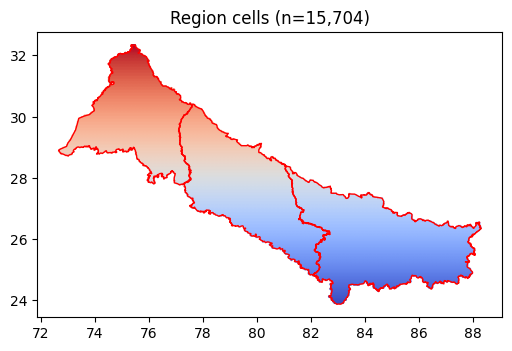

In [4]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 1 — Region grid + mask  (files already cropped on disk)        ║
# ╚══════════════════════════════════════════════════════════════════════╝
# Files are PRE-CROPPED, so the file grid IS the region window already.
_sample = sorted(glob.glob(os.path.join(GCM_DIR_005, "*.nc")))[0]
_d = xr.open_dataset(_sample)
reg_lats = _d["lat"].values if "lat" in _d.coords else _d["latitude"].values
reg_lons = _d["lon"].values if "lon" in _d.coords else _d["longitude"].values
_d.close()
if reg_lats[0] > reg_lats[-1]:
    reg_lats = reg_lats[::-1]
nr_lat, nr_lon = len(reg_lats), len(reg_lons)
print(f"✅ Cropped file grid: {nr_lat} × {nr_lon} = {nr_lat*nr_lon:,} cells")
print(f"   lat {reg_lats[0]:.3f} → {reg_lats[-1]:.3f} | lon {reg_lons[0]:.3f} → {reg_lons[-1]:.3f}")

# shapefile mask on the (already-cropped) grid
gdf = gpd.read_file(SHAPEFILE)
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)
elif gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)
region_geom = gdf.union_all() if hasattr(gdf, 'union_all') else gdf.unary_union

lon_g, lat_g = np.meshgrid(reg_lons, reg_lats)
try:
    from shapely import contains_xy
    region_mask = contains_xy(region_geom, lon_g.ravel(), lat_g.ravel()).reshape(lon_g.shape)
except Exception:
    from shapely.vectorized import contains
    region_mask = contains(region_geom, lon_g.ravel(), lat_g.ravel()).reshape(lon_g.shape)

n_region = int(region_mask.sum())
assert n_region > 0, "0 cells inside shapefile — check CRS / files"
flat_idx = np.where(region_mask.ravel())[0]
ii_loc, jj_loc = np.unravel_index(flat_idx, (nr_lat, nr_lon))
print(f"✅ Region mask : {n_region:,} cells")

# static features — lat + lon only (NO elevation)
STATIC_COLS = np.column_stack([reg_lats[ii_loc], reg_lons[jj_loc]]).astype(np.float32)
print(f"✅ Static features {STATIC_COLS.shape} [lat, lon]")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(reg_lons[jj_loc], reg_lats[ii_loc], s=1, c=reg_lats[ii_loc], cmap="coolwarm")
gdf.boundary.plot(ax=ax, color="red", lw=1)
ax.set_title(f"Region cells (n={n_region:,})"); plt.show()

In [5]:
# ── MEMORY PRE-FLIGHT CHECK  (run BEFORE training) ────────────────────
import psutil

def ram_now_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9

avail_gb = psutil.virtual_memory().available / 1e9
total_gb = psutil.virtual_memory().total / 1e9
print(f"System RAM   : {total_gb:.1f} GB total, {avail_gb:.1f} GB available now")
print(f"Process using: {ram_now_gb():.2f} GB currently\n")

# ── estimate peak memory during inference (the part that crashed before) ──
n_train_days = (TRAIN_END - TRAIN_START + 1) * 366
n_test_days  = (TEST_END  - TEST_START  + 1) * 366
bytes_per_day = nr_lat * nr_lon * 4

gb_infer_train = (n_train_days * bytes_per_day) / 1e9
gb_infer_test  = (n_test_days  * bytes_per_day) / 1e9

# year cache: compact (days × n_region) arrays for every loaded year
n_years_gcm = TEST_END - TRAIN_START + 1
n_years_obs = TEST_END - TRAIN_START + 1
gb_cache = ((n_years_gcm + n_years_obs) * 366 * n_region * 4) / 1e9

# per-month training array: ~31 days × n_region × N_FEATURES, ×3 (X, scaled, val)
gb_train_arrays = (31 * (TRAIN_END-TRAIN_START+1) * n_region * N_FEATURES * 4 * 3) / 1e9

print(f"Cropped grid : {nr_lat} × {nr_lon} = {nr_lat*nr_lon:,} cells")
print(f"Region cells : {n_region:,}  (waste ratio {nr_lat*nr_lon/n_region:.1f}x)\n")
print(f"Est. year-cache (all years)        : ~{gb_cache:.2f} GB")
print(f"Est. per-month training arrays     : ~{gb_train_arrays:.2f} GB")
print(f"Est. inference peak (train period) : ~{gb_infer_train:.2f} GB")
print(f"Est. inference peak (test period)  : ~{gb_infer_test:.2f} GB\n")

peak_est = gb_cache + max(gb_train_arrays, gb_infer_train)
print(f"Rough worst-case peak ≈ {peak_est:.2f} GB")

if peak_est < avail_gb * 0.7:
    print(f"✅ SAFE — estimated peak ({peak_est:.2f} GB) is well under "
          f"70% of available RAM ({avail_gb*0.7:.1f} GB). OK to run.")
elif peak_est < avail_gb:
    print(f"⚠ TIGHT — peak ({peak_est:.2f} GB) fits but with little margin. "
          f"Watch the RAM print during training.")
else:
    print(f"❌ RISKY — estimated peak ({peak_est:.2f} GB) exceeds available RAM "
          f"({avail_gb:.1f} GB). Reduce grid size or batch.")

System RAM   : 33.7 GB total, 31.8 GB available now
Process using: 0.86 GB currently

Cropped grid : 190 × 333 = 63,270 cells
Region cells : 15,704  (waste ratio 4.0x)

Est. year-cache (all years)        : ~1.47 GB
Est. per-month training arrays     : ~0.73 GB
Est. inference peak (train period) : ~2.32 GB
Est. inference peak (test period)  : ~0.65 GB

Rough worst-case peak ≈ 3.79 GB
✅ SAFE — estimated peak (3.79 GB) is well under 70% of available RAM (22.2 GB). OK to run.


In [6]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 2 — Helpers: I/O, MLP, QM, trainer                            ║
# ║  Adapted for temperature: no elevation, no Softplus, no clip(0),     ║
# ║  no log transform, no y>=0 filter                                    ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── build file-index once: map year → filepath for GCM and OBS ──────
def _build_file_index(directory, prefix_hint=None):
    """Scan a directory of yearly .nc files, return {year: filepath}."""
    index = {}
    for f in sorted(glob.glob(os.path.join(directory, "*.nc"))):
        # extract 4-digit year from filename
        nums = re.findall(r'(\d{4})', os.path.basename(f))
        if nums:
            yr = int(nums[-1])  # last 4-digit number is usually the year
            index[yr] = f
    return index

GCM_FILES = _build_file_index(GCM_DIR_005)
OBS_FILES = _build_file_index(OBS_DIR_005)
print(f"GCM file index : {min(GCM_FILES)}-{max(GCM_FILES)} ({len(GCM_FILES)} years)")
print(f"OBS file index : {min(OBS_FILES)}-{max(OBS_FILES)} ({len(OBS_FILES)} years)")

# ── auto-detect variable name in obs files ───────────────────────────
_obs_sample = xr.open_dataset(list(OBS_FILES.values())[0])
_candidate_vars = [v for v in _obs_sample.data_vars
                   if _obs_sample[v].ndim >= 2 and v not in ("lat","lon","time","spatial_ref")]
OBS_VAR = _candidate_vars[0] if _candidate_vars else "tmin"
print(f"OBS variable   : '{OBS_VAR}'  (auto-detected from {os.path.basename(list(OBS_FILES.values())[0])})")
_obs_sample.close()

# ── per-YEAR cache ───────────────────────────────────────────────────
_YEAR_CACHE = {}

def _get_year(kind, yr):
    """Load one year of data, extract region cells, cache in memory.
    kind='gcm' or 'obs'."""
    key = (kind, yr)
    if key in _YEAR_CACHE:
        return _YEAR_CACHE[key]

    files = GCM_FILES if kind == "gcm" else OBS_FILES
    varname = VAR_NAME if kind == "gcm" else OBS_VAR

    if yr not in files:
        _YEAR_CACHE[key] = None
        return None

    dsc = xr.open_dataset(files[yr])
    t   = pd.to_datetime(dsc["time"].values)
    la  = dsc["lat"].values if "lat" in dsc.coords else dsc["latitude"].values
    arr = dsc[varname].values.astype(np.float32)
    dsc.close()

    # handle fill values
    arr = np.where((arr < -9000) | (arr > 200), np.nan, arr)

    if la[0] > la[-1]:
        arr = arr[:, ::-1, :]

    data = arr[:, ii_loc, jj_loc]   # (T_year, n_region)
    out  = (data, t, t.day_of_year.values.astype(np.int32))
    _YEAR_CACHE[key] = out
    return out

def load_gcm_month(years, month):
    data_list, doy_list, date_list = [], [], []
    for yr in years:
        r = _get_year("gcm", yr)
        if r is None: continue
        data, dates, doys = r
        m_mask = dates.month == month
        if not m_mask.any(): continue
        data_list.append(data[m_mask])
        doy_list.append(doys[m_mask])
        date_list.append(dates[m_mask])
    if not data_list:
        return None, None, None
    data  = np.concatenate(data_list, axis=0)
    doys  = np.concatenate(doy_list)
    dates = date_list[0].append(date_list[1:]) if len(date_list) > 1 else date_list[0]
    return data, doys, dates

def load_obs_month(years, month):
    data_list = []
    for yr in years:
        r = _get_year("obs", yr)
        if r is None: continue
        data, dates, _ = r
        m_mask = dates.month == month
        if m_mask.any():
            data_list.append(data[m_mask])
    if not data_list:
        return None
    return np.concatenate(data_list, axis=0)

# ── feature builder (5 features: gcm, lat, lon, sin_doy, cos_doy) ───
def build_X(gcm_days, doys):
    n_days = len(doys)
    sin_d  = np.sin(2*np.pi*doys/365.25).astype(np.float32)
    cos_d  = np.cos(2*np.pi*doys/365.25).astype(np.float32)
    X = np.empty((n_days*n_region, N_FEATURES), dtype=np.float32)
    X[:, 0] = gcm_days.ravel()
    X[:, 1] = np.tile(STATIC_COLS[:, 0], n_days)   # lat
    X[:, 2] = np.tile(STATIC_COLS[:, 1], n_days)   # lon
    X[:, 3] = np.repeat(sin_d, n_region)
    X[:, 4] = np.repeat(cos_d, n_region)
    return X

# ── MLP — NO Softplus (temperature can be negative) ─────────────────
class MLPNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        act_map = {"gelu": nn.GELU, "leaky_relu": nn.LeakyReLU, "relu": nn.ReLU}
        act = act_map.get(cfg.get("activation", "relu"), nn.ReLU)
        layers, prev = [], N_FEATURES
        for h in cfg["hidden"]:
            layers.append(nn.Linear(prev, h))
            if cfg.get("batchnorm", True):
                layers.append(nn.BatchNorm1d(h))
            layers += [act(), nn.Dropout(cfg.get("dropout", 0.2))]
            prev = h
        layers.append(nn.Linear(prev, 1))    # ← plain linear, NO Softplus
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)

DEFAULT_CFG = {"hidden": [128, 128, 64, 64], "dropout": 0.38625281322982374,
               "lr": 0.0023628864184236428,
               "weight_decay": 3.3347927286375814e-07, "batch_size": 32768,
               "activation": "leaky_relu", "batchnorm": False,
               "log_transform": False, "epochs": EPOCHS}

def load_cfg():
    if os.path.exists(BEST_PARAMS):
        with open(BEST_PARAMS) as f:
            c = json.load(f)
        c.setdefault("epochs", EPOCHS)
        c["log_transform"] = False   # force off for temperature
        print(f"✅ Using tuned config: {c['hidden']} | lr={c['lr']:.2e} "
              f"| drop={c['dropout']:.2f}")
        return c
    print("⚠ No optuna_best_params.json found — using DEFAULT_CFG")
    return dict(DEFAULT_CFG)

# ── predict — NO log, NO clip(0) ─────────────────────────────────────
def _predict(model, X_sc, bs):
    """Predict temperature — no log inverse, no clipping."""
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X_sc), bs):
            xb = torch.from_numpy(X_sc[i:i+bs]).to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                p = model(xb)
            out.append(p.float().cpu().numpy())
    return np.concatenate(out)

def _rmse_val(model, X_sc, y, bs):
    return float(np.sqrt(mean_squared_error(y, _predict(model, X_sc, bs))))

# ── trainer ──────────────────────────────────────────────────────────
def train_model(cfg, X_tr, y_tr, X_val=None, y_val=None,
                trial=None, epochs=None, patience=10, tag=""):
    import optuna
    epochs = epochs or cfg.get("epochs", EPOCHS)
    bs     = cfg["batch_size"]

    model = MLPNet(cfg).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg["lr"],
                             weight_decay=cfg.get("weight_decay", 0.0))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.MSELoss()
    gscale = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    y_in = y_tr.astype(np.float32)      # NO log1p for temperature
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_in)),
        batch_size=bs, shuffle=True, drop_last=True,
        pin_memory=USE_AMP, num_workers=2 if USE_AMP else 0,
        persistent_workers=USE_AMP)

    best_val, best_state, bad = np.inf, None, 0
    hist = {"train_loss": [], "val_rmse": []}
    for ep in range(1, epochs + 1):
        model.train(); run = 0.0
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                loss = crit(model(Xb), yb)
            gscale.scale(loss).backward(); gscale.step(opt); gscale.update()
            run += loss.item()
        sched.step()
        tl = run / max(1, len(loader))
        hist["train_loss"].append(tl)

        if X_val is not None:
            vr = _rmse_val(model, X_val, y_val, bs)
            hist["val_rmse"].append(vr)
            if trial is not None:
                trial.report(vr, ep)
                if trial.should_prune():
                    raise optuna.TrialPruned()
            if vr < best_val - 1e-4:
                best_val = vr; bad = 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
            # ── print every epoch (train loss + val RMSE + running best) ──
            print(f"    {tag} epoch {ep:>3} | loss={tl:.4f} | val_RMSE={vr:.4f} | best={best_val:.4f} | bad={bad}", flush=True)
            if bad >= patience:
                break
        else:
            print(f"    {tag} epoch {ep:>3} | loss={tl:.4f}", flush=True)
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, (best_val if np.isfinite(best_val) else hist["train_loss"][-1]), hist

# ── sanity check ─────────────────────────────────────────────────────
print(f"\n✅ Helpers ready (region: {n_region:,} cells).  Sanity check — January {TRAIN_START}...")
_g, _d, _ = load_gcm_month([TRAIN_START], 1)
_c        = load_obs_month([TRAIN_START], 1)
if _g is not None:
    print(f"   GCM    : {_g.shape}  min={np.nanmin(_g):.2f}  max={np.nanmax(_g):.2f} {UNITS}")
if _c is not None:
    print(f"   CHIRTS : {_c.shape}  min={np.nanmin(_c):.2f}  max={np.nanmax(_c):.2f} {UNITS}")

# ── QM transfer functions — NO clip(0) ───────────────────────────────
def fit_qmap_vectorized(obs_2d, his_2d):
    obs_clean = np.where(np.isnan(obs_2d), np.nanmedian(obs_2d, axis=0), obs_2d)
    his_clean = np.where(np.isnan(his_2d), np.nanmedian(his_2d, axis=0), his_2d)
    obs_q = np.quantile(obs_clean, Q_LEVELS, axis=0).T.astype(np.float32)
    his_q = np.quantile(his_clean, Q_LEVELS, axis=0).T.astype(np.float32)
    return obs_q, his_q

def apply_qmap_vectorized(his_2d, obs_q, his_q):
    bc = np.full_like(his_2d, np.nan)
    for k in range(n_region):
        vals = his_2d[:, k]; nm = np.isnan(vals)
        if np.any(~nm) and not np.isnan(his_q[k, 0]):
            _, uid = np.unique(his_q[k], return_index=True)
            bc[~nm, k] = np.interp(vals[~nm], his_q[k, uid], obs_q[k, uid])  # NO clip(0)
    return bc

GCM file index : 1980-2014 (35 years)
OBS file index : 1983-2014 (32 years)
OBS variable   : 'tmin'  (auto-detected from CHIRTS_TMIN_1983.nc)

✅ Helpers ready (region: 15,704 cells).  Sanity check — January 1983...
   GCM    : (31, 15704)  min=-1.56  max=14.93 °C
   CHIRTS : (31, 15704)  min=0.15  max=17.88 °C


In [7]:
# # ╔══════════════════════════════════════════════════════════════════════╗
# # ║  Cell 3 — OPTUNA: July + January, 10 trials, RESUMABLE              ║
# # ║  Adapted for temperature: no y>=0 filter, no log_transform search    ║
# # ║  Funnel architectures only · relu / gelu / leaky_relu                ║
# # ╚══════════════════════════════════════════════════════════════════════╝
# import optuna
# from optuna.samplers import TPESampler
# from optuna.pruners  import MedianPruner

# TUNE_MONTHS = [7, 1]
# N_TRIALS    = 10
# TUNE_EPOCHS = 25
# VAL_YEARS   = 4

# # resume support: if a previous session's db was uploaded with the dataset,
# # copy it into working so the study continues from where it stopped
# import shutil
# _prev_db = os.path.join(DATA, "optuna_study.db")
# if os.path.exists(_prev_db) and not os.path.exists(OPTUNA_DB):
#     shutil.copy(_prev_db, OPTUNA_DB)
#     print("Resuming study from uploaded optuna_study.db")

# # ── load both months once, split by YEAR ─────────────────────────────
# month_data = {}
# cut = TRAIN_END - VAL_YEARS
# for m in TUNE_MONTHS:
#     g, doy, dates = load_gcm_month(range(TRAIN_START, TRAIN_END + 1), m)
#     c             = load_obs_month(range(TRAIN_START, TRAIN_END + 1), m)
#     n = min(len(g), len(c))
#     X = build_X(g[:n], doy[:n]); y = c[:n].reshape(-1)
#     yr = np.repeat(dates[:n].year.values, n_region)
#     fin = np.isfinite(X).all(1) & np.isfinite(y)          # ← NO y>=0 for temperature
#     tr, va = fin & (yr <= cut), fin & (yr > cut)
#     sc = StandardScaler().fit(X[tr])
#     month_data[m] = dict(
#         Xtr=sc.transform(X[tr]).astype(np.float32), ytr=y[tr],
#         Xva=sc.transform(X[va]).astype(np.float32), yva=y[va],
#         ystd=float(np.nanstd(y[va])))
#     print(f"{MONTH_NAMES[m-1]}: train={tr.sum():,}  val={va.sum():,}  "
#           f"obs std={month_data[m]['ystd']:.2f} {UNITS}")
#     del X, y, g, c

# def objective(trial):
#     n_layers = trial.suggest_int("n_layers", 2, 4)
#     hidden, prev = [], 512
#     for i in range(n_layers):                      # funnel constraint
#         choices = [c for c in [512, 256, 128, 64] if c <= prev]
#         h = trial.suggest_categorical(f"u{i}_{prev}", choices)
#         hidden.append(h); prev = h
#     cfg = {
#         "hidden"       : hidden,
#         "dropout"      : trial.suggest_float("dropout", 0.0, 0.4),
#         "lr"           : trial.suggest_float("lr", 1e-4, 5e-3, log=True),
#         "weight_decay" : trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True),
#         "batch_size"   : trial.suggest_categorical("batch_size",
#                                                    [16384, 32768, 65536, 131072]),
#         "activation"   : trial.suggest_categorical("activation",
#                                                    ["relu", "gelu", "leaky_relu"]),
#         "batchnorm"    : trial.suggest_categorical("batchnorm", [True, False]),
#         "log_transform": False,            # ← forced off for temperature
#     }
#     score = 0.0
#     for k, m in enumerate(TUNE_MONTHS):
#         d = month_data[m]
#         _, rmse, _ = train_model(cfg, d["Xtr"], d["ytr"], d["Xva"], d["yva"],
#                                  trial=trial if k == 0 else None,
#                                  epochs=TUNE_EPOCHS, patience=8)
#         trial.set_user_attr(f"rmse_{MONTH_NAMES[m-1]}", float(rmse))
#         score += (rmse / d["ystd"]) / len(TUNE_MONTHS)
#     return score

# study = optuna.create_study(
#     direction="minimize",
#     sampler=TPESampler(seed=SEED),
#     pruner=MedianPruner(n_warmup_steps=6),
#     study_name="region_tmin",
#     storage=f"sqlite:///{OPTUNA_DB}",
#     load_if_exists=True,
# )
# done = len([t for t in study.trials
#             if t.state == optuna.trial.TrialState.COMPLETE])
# remaining = max(N_TRIALS - done, 0)
# print(f"Trials complete: {done}  |  running {remaining} more")
# if remaining:
#     study.optimize(objective, n_trials=remaining, show_progress_bar=True)

# print(f"\nBest combined score : {study.best_value:.4f} (relative RMSE; <1 beats mean)")
# print(f"  July    RMSE: {study.best_trial.user_attrs.get('rmse_Jul'):.3f} {UNITS}")
# print(f"  January RMSE: {study.best_trial.user_attrs.get('rmse_Jan'):.3f} {UNITS}")
# print("Best hyperparameters:")
# for k, v in study.best_params.items():
#     print(f"   {k:<16}: {v}")

# # ── save config for Cell 4 + full history CSV ────────────────────────
# bp = study.best_params
# hidden, prev = [], 512
# for i in range(bp["n_layers"]):
#     hidden.append(bp[f"u{i}_{prev}"]); prev = hidden[-1]
# BEST = {"hidden": hidden, "dropout": float(bp["dropout"]), "lr": float(bp["lr"]),
#         "weight_decay": float(bp["weight_decay"]), "batch_size": int(bp["batch_size"]),
#         "activation": bp["activation"], "batchnorm": bool(bp["batchnorm"]),
#         "log_transform": False, "epochs": EPOCHS,
#         "tuned_on_months": TUNE_MONTHS, "best_score": float(study.best_value)}
# with open(BEST_PARAMS, "w") as f:
#     json.dump(BEST, f, indent=2)

# rows = []
# for t in study.trials:
#     r = {"trial": t.number, "state": str(t.state), "value": t.value}
#     r.update(t.params); r.update(t.user_attrs); rows.append(r)
# pd.DataFrame(rows).to_csv(f"{OUT_DIR}/optuna_trials_full.csv", index=False)
# print(f"\n✅ Saved best config → {BEST_PARAMS}")
# print(f"✅ Saved full history → {OUT_DIR}/optuna_trials_full.csv")

# try:
#     from optuna.visualization.matplotlib import (plot_optimization_history,
#                                                   plot_param_importances)
#     plot_optimization_history(study).figure.savefig(
#         f"{OUT_DIR}/optuna_history.png", dpi=150, bbox_inches="tight")
#     plot_param_importances(study).figure.savefig(
#         f"{OUT_DIR}/optuna_importance.png", dpi=150, bbox_inches="tight")
#     plt.show()
# except Exception as e:
#     print("Plot skipped:", e)

# for m in TUNE_MONTHS: month_data[m].clear()

In [8]:
import json, os
best = {
    "hidden": [512, 128, 128, 128],
    "dropout": 0.13504606856145118,
    "lr": 0.003999220074578466,
    "weight_decay": 4.1306144511331625e-07,
    "batch_size": 4096,
    "activation": "relu",
    "batchnorm": True,
    "epochs": 200,
    "log_transform": False
}
os.makedirs(os.path.dirname(BEST_PARAMS), exist_ok=True)
with open(BEST_PARAMS, "w") as f:
    json.dump(best, f, indent=2)
print(f"✅ Wrote best params → {BEST_PARAMS}")

✅ Wrote best params → /kaggle/working/tmin_downscaling_output/optuna_best_params.json


In [9]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 4 — FULL PIPELINE  (Train → Infer → QM)                       ║
# ║  Same logic as precip notebook except:                               ║
# ║    • fin = isfinite only (no y>=0)                                   ║
# ║    • _predict (no log, no clip)                                      ║
# ║    • NetCDF var = "tasmin"                                           ║
# ╚══════════════════════════════════════════════════════════════════════╝
CFG          = load_cfg()
BS           = CFG["batch_size"]
VAL_YEARS_FIN = 3
PATIENCE      = 15

print(f"\nConfig: hidden={CFG['hidden']} dropout={CFG['dropout']:.2f} "
      f"lr={CFG['lr']:.2e} wd={CFG['weight_decay']:.1e} bs={BS} "
      f"act={CFG['activation']} bn={CFG['batchnorm']}")

# ── resume-safe: load any QM TFs already on disk ─────────────────────
tf_store = {}
if os.path.exists(QM_TF_PATH):
    with np.load(QM_TF_PATH) as z:
        tf_store = {k: z[k] for k in z.files}
    print(f"   Loaded {len(tf_store)//2} existing QM month(s) from disk")

train_summary, epoch_metrics = {}, {}
cut_fin = TRAIN_END - VAL_YEARS_FIN

# ════════════════════════ PART 1 — TRAINING ═══════════════════════════
print("\n" + "="*60 + "\n  TRAINING — 12 monthly MLPs (Tmin)\n" + "="*60)
for month in range(1, 13):
    mname, mstr = MONTH_NAMES[month-1], f"m{month:02d}"
    mp = os.path.join(MODEL_DIR, f"mlp_{mstr}.pth")
    have_qm = (f"{mstr}_obs_q" in tf_store) and (f"{mstr}_his_q" in tf_store)
    if os.path.exists(mp) and have_qm:
        print(f"  ✓ {mname} already trained + QM present — skipping", flush=True)
        continue

    print(f"\n{'─'*55}\n  [{month:02d}/12] {mname}  {pd.Timestamp.now():%H:%M:%S}\n{'─'*55}", flush=True)
    gcm_tr, doy_tr, dates_tr = load_gcm_month(range(TRAIN_START, TRAIN_END+1), month)
    obs_tr                   = load_obs_month(range(TRAIN_START, TRAIN_END+1), month)
    if gcm_tr is None or obs_tr is None:
        print("  ✗ missing data"); continue
    n = min(len(gcm_tr), len(obs_tr))
    gcm_tr, obs_tr, doy_tr, dates_tr = gcm_tr[:n], obs_tr[:n], doy_tr[:n], dates_tr[:n]

    X_all = build_X(gcm_tr, doy_tr)
    y_all = obs_tr.reshape(-1)
    yrlab = np.repeat(dates_tr.year.values, n_region)
    fin   = np.isfinite(X_all).all(1) & np.isfinite(y_all)     # ← NO y>=0
    fit_m = fin & (yrlab <= cut_fin)
    val_m = fin & (yrlab >  cut_fin)
    print(f"  fit={int(fit_m.sum()):,}  val={int(val_m.sum()):,} "
          f"(val yrs {cut_fin+1}-{TRAIN_END})", flush=True)

    scaler = StandardScaler().fit(X_all[fit_m])
    joblib.dump(scaler, os.path.join(SCALER_DIR, f"scaler_{mstr}.joblib"))
    Xfit = scaler.transform(X_all[fit_m]).astype(np.float32); yfit = y_all[fit_m]
    Xval = scaler.transform(X_all[val_m]).astype(np.float32); yval = y_all[val_m]

    model, best_val, hist = train_model(CFG, Xfit, yfit, Xval, yval,
                                        epochs=CFG["epochs"], patience=PATIENCE, tag=mname)
    torch.save(model.state_dict(), mp)
    epoch_metrics[month] = hist
    print(f"  early-stop best val RMSE={best_val:.4f}  (epochs run={len(hist['train_loss'])})",
          flush=True)

    # train metric (whole train period) + test metric
    Xtr_sc = scaler.transform(X_all[fin]).astype(np.float32)
    p_tr   = _predict(model, Xtr_sc, BS)
    rmse_tr = float(np.sqrt(mean_squared_error(y_all[fin], p_tr)))
    r2_tr   = float(r2_score(y_all[fin], p_tr))

    gcm_te, doy_te, _ = load_gcm_month(range(TEST_START, TEST_END+1), month)
    obs_te            = load_obs_month(range(TEST_START, TEST_END+1), month)
    rmse_te = r2_te = np.nan
    if gcm_te is not None and obs_te is not None:
        nte = min(len(gcm_te), len(obs_te))
        Xte = build_X(gcm_te[:nte], doy_te[:nte]); yte = obs_te[:nte].reshape(-1)
        vte = np.isfinite(Xte).all(1) & np.isfinite(yte)       # ← NO y>=0
        p_te = _predict(model, scaler.transform(Xte[vte]).astype(np.float32), BS)
        rmse_te = float(np.sqrt(mean_squared_error(yte[vte], p_te)))
        r2_te   = float(r2_score(yte[vte], p_te))
    train_summary[month] = (rmse_tr, r2_tr, rmse_te, r2_te)
    print(f"  TR RMSE={rmse_tr:.4f} R²={r2_tr:.4f} | TE RMSE={rmse_te:.4f} R²={r2_te:.4f}", flush=True)

    # ── fit QM on full-train predictions vs obs ──────────────────────
    p_full = _predict(model, Xtr_sc, BS)
    p_grid   = np.full(len(y_all), np.nan, np.float32); p_grid[fin] = p_full
    p_grid   = p_grid.reshape(n, n_region)
    obs_q, his_q = fit_qmap_vectorized(obs_tr, p_grid)
    tf_store[f"{mstr}_obs_q"] = obs_q
    tf_store[f"{mstr}_his_q"] = his_q
    np.savez_compressed(QM_TF_PATH, **tf_store)
    pd.DataFrame({"epoch": range(1, len(hist["train_loss"])+1),
                  "train_loss": hist["train_loss"],
                  "val_rmse": (hist["val_rmse"] + [np.nan]*(len(hist["train_loss"])-len(hist["val_rmse"])))
                 }).to_csv(os.path.join(OUT_DIR, f"epoch_metrics_{mstr}.csv"), index=False)
    print("  ✓ QM fitted + saved", flush=True)
    try:
        print(f"  RAM now: {ram_now_gb():.2f} GB", flush=True)
    except Exception:
        pass

    del X_all, y_all, Xfit, Xval, Xtr_sc, gcm_tr, obs_tr, p_full, p_grid
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print("\n✅ All models + QM TFs saved!")
print(f"\n  {'Month':<6}{'TR_RMSE':>10}{'TR_R²':>9}{'TE_RMSE':>10}{'TE_R²':>9}")
print("  " + "─"*44)
for m in range(1, 13):
    if m in train_summary:
        a,b,c,d = train_summary[m]
        print(f"  {MONTH_NAMES[m-1]:<6}{a:>10.4f}{b:>9.4f}{c:>10.4f}{d:>9.4f}")

# ════════════════════════ PART 2 — INFERENCE ══════════════════════════
print("\n" + "="*60 + "\n  INFERENCE\n" + "="*60)
def predict_period(years, out_file, label):
    compact_chunks, time_chunks = [], []
    for month in range(1, 13):
        mstr = f"m{month:02d}"
        mp   = os.path.join(MODEL_DIR,  f"mlp_{mstr}.pth")
        sp   = os.path.join(SCALER_DIR, f"scaler_{mstr}.joblib")
        if not os.path.exists(mp): continue
        model = MLPNet(CFG).to(DEVICE)
        model.load_state_dict(torch.load(mp, map_location=DEVICE)); model.eval()
        sc = joblib.load(sp)
        g, doy, dates = load_gcm_month(years, month)
        if g is None: continue
        p = _predict(model, sc.transform(build_X(g, doy)).astype(np.float32),
                     BS).reshape(len(g), n_region)
        compact_chunks.append(p)                       # keep COMPACT (days × n_region)
        time_chunks.append(pd.to_datetime(dates))
        del model, sc, g
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        print(f"  {MONTH_NAMES[month-1]} \u2713", end="  ", flush=True)
    print()

    compact = np.concatenate(compact_chunks, axis=0)   # (total_days, n_region)
    t = pd.to_datetime(np.concatenate([tc.values for tc in time_chunks]))
    idx = np.argsort(t); compact, t = compact[idx], t[idx]
    del compact_chunks, time_chunks; gc.collect()

    # allocate the full grid ONCE, not per-day
    arr = np.full((len(t), nr_lat, nr_lon), np.nan, dtype=np.float32)
    arr[:, ii_loc, jj_loc] = compact
    del compact; gc.collect()

    xr.Dataset({VAR_NAME: (["time","lat","lon"], arr,
                       {"units": UNITS, "long_name": f"MLP daily 0.05\u00b0 {VAR_LABEL} {label}"})},
               coords={"time": t, "lat": reg_lats, "lon": reg_lons}
              ).to_netcdf(out_file, encoding={VAR_NAME:{"zlib":True,"complevel":1,"dtype":"float32"}})
    print(f"\u2705 {label}: {arr.shape}  ({os.path.getsize(out_file)/1e6:.1f} MB)", flush=True)
    del arr; gc.collect()

predict_period(range(TRAIN_START, TRAIN_END+1), MLP_DAILY_TR, "Training MLP")
predict_period(range(TEST_START,  TEST_END +1), MLP_DAILY_TE, "Testing MLP")

# ════════════════════════ PART 3 — QM BIAS CORRECTION ═════════════════
print("\n" + "="*60 + "\n  QM BIAS CORRECTION\n" + "="*60)
def apply_qm_period(mlp_nc, out_file, label):
    ds = xr.open_dataset(mlp_nc)
    compact_chunks, time_chunks = [], []
    for month in range(1, 13):
        mstr  = f"m{month:02d}"
        obs_q = tf_store.get(f"{mstr}_obs_q"); his_q = tf_store.get(f"{mstr}_his_q")
        if obs_q is None: continue
        da = ds[VAR_NAME].sel(time=ds[VAR_NAME].time.dt.month == month)
        if len(da.time) == 0: continue
        bc = apply_qmap_vectorized(da.values[:, ii_loc, jj_loc], obs_q, his_q)
        compact_chunks.append(bc)                       # keep COMPACT
        time_chunks.append(pd.to_datetime(da.time.values))
        print(f"  {MONTH_NAMES[month-1]} \u2713", end="  ", flush=True)
    print(); ds.close()

    compact = np.concatenate(compact_chunks, axis=0)
    t = pd.to_datetime(np.concatenate([tc.values for tc in time_chunks]))
    idx = np.argsort(t); compact, t = compact[idx], t[idx]
    del compact_chunks, time_chunks; gc.collect()

    arr = np.full((len(t), nr_lat, nr_lon), np.nan, dtype=np.float32)
    arr[:, ii_loc, jj_loc] = compact
    del compact; gc.collect()

    xr.Dataset({VAR_NAME: (["time","lat","lon"], arr,
                       {"units": UNITS, "long_name": f"QM BC daily 0.05\u00b0 {VAR_LABEL} {label}"})},
               coords={"time": t, "lat": reg_lats, "lon": reg_lons}
              ).to_netcdf(out_file, encoding={VAR_NAME:{"zlib":True,"complevel":1,"dtype":"float32"}})
    print(f"\u2705 {label}: {arr.shape}  ({os.path.getsize(out_file)/1e6:.1f} MB)", flush=True)
    del arr; gc.collect()

apply_qm_period(MLP_DAILY_TR, BC_DAILY_TR, "Training BC")
apply_qm_period(MLP_DAILY_TE, BC_DAILY_TE, "Testing BC")

print("\n" + "="*60 + f"\n  TRAINING + INFERENCE + QM BC COMPLETE → {OUT_DIR}\n" + "="*60)
print(f"Finished : {pd.Timestamp.now()}", flush=True)

✅ Using tuned config: [512, 128, 128, 128] | lr=4.00e-03 | drop=0.14

Config: hidden=[512, 128, 128, 128] dropout=0.14 lr=4.00e-03 wd=4.1e-07 bs=4096 act=relu bn=True

  TRAINING — 12 monthly MLPs (Tmin)

───────────────────────────────────────────────────────
  [01/12] Jan  09:01:51
───────────────────────────────────────────────────────
  fit=10,710,128  val=1,460,472 (val yrs 2005-2007)
    Jan epoch   1 | loss=5.7301 | val_RMSE=2.4755 | best=2.4755 | bad=0
    Jan epoch   2 | loss=4.8074 | val_RMSE=2.4991 | best=2.4755 | bad=1
    Jan epoch   3 | loss=4.6721 | val_RMSE=2.5145 | best=2.4755 | bad=2
    Jan epoch   4 | loss=4.5744 | val_RMSE=2.5032 | best=2.4755 | bad=3
    Jan epoch   5 | loss=4.5109 | val_RMSE=2.5240 | best=2.4755 | bad=4
    Jan epoch   6 | loss=4.4706 | val_RMSE=2.5369 | best=2.4755 | bad=5
    Jan epoch   7 | loss=4.4395 | val_RMSE=2.5210 | best=2.4755 | bad=6
    Jan epoch   8 | loss=4.4185 | val_RMSE=2.5568 | best=2.4755 | bad=7
    Jan epoch   9 | loss=4.3995

In [10]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CHECK: Do elevation, CHIRTS, and GCM grids match at 0.05°?          ║
# ╚══════════════════════════════════════════════════════════════════════╝

import glob, os
elev_candidates = glob.glob("/kaggle/input/**/elevation*.nc", recursive=True)
if not elev_candidates:
    print("❌ No elevation .nc file found in any attached dataset.")
    print("   Attach the dataset containing elevation_005deg_india.nc and re-run.")
else:
    ELEV_PATH = elev_candidates[0]
    print(f"Found: {ELEV_PATH}\n")

    de = xr.open_dataset(ELEV_PATH)
    elev_lat = de["lat"].values if "lat" in de.coords else de["latitude"].values
    elev_lon = de["lon"].values if "lon" in de.coords else de["longitude"].values
    de.close()
    if elev_lat[0] > elev_lat[-1]: elev_lat = elev_lat[::-1]

    obs_sample = sorted(glob.glob(os.path.join(OBS_DIR_005, "*.nc")))[0]
    do = xr.open_dataset(obs_sample)
    obs_lat = do["lat"].values if "lat" in do.coords else do["latitude"].values
    obs_lon = do["lon"].values if "lon" in do.coords else do["longitude"].values
    do.close()
    if obs_lat[0] > obs_lat[-1]: obs_lat = obs_lat[::-1]

    gcm_sample = sorted(glob.glob(os.path.join(GCM_DIR_005, "*.nc")))[0]
    dg = xr.open_dataset(gcm_sample)
    gcm_lat = dg["lat"].values if "lat" in dg.coords else dg["latitude"].values
    gcm_lon = dg["lon"].values if "lon" in dg.coords else dg["longitude"].values
    dg.close()
    if gcm_lat[0] > gcm_lat[-1]: gcm_lat = gcm_lat[::-1]

    print(f"{'Source':<12} {'Shape (lat×lon)':<18} {'Lat range':<28} {'Lon range':<28}")
    print("─" * 86)
    for name, la, lo in [("Elevation", elev_lat, elev_lon),
                          ("CHIRTS", obs_lat, obs_lon),
                          ("GCM 0.05°", gcm_lat, gcm_lon)]:
        print(f"{name:<12} {f'{len(la)}×{len(lo)}':<18} "
              f"{la[0]:.6f} → {la[-1]:.6f}    {lo[0]:.6f} → {lo[-1]:.6f}")

    print(f"\n{'Comparison':<30} {'Lat match?':<15} {'Lon match?':<15} {'Max lat diff':<18} {'Max lon diff'}")
    print("─" * 95)
    for name, la, lo, la2, lo2 in [
        ("Elev vs GCM",    elev_lat, elev_lon, gcm_lat, gcm_lon),
        ("Elev vs CHIRTS", elev_lat, elev_lon, obs_lat, obs_lon),
        ("CHIRTS vs GCM",  obs_lat,  obs_lon,  gcm_lat, gcm_lon)]:
        min_lat, max_lat = max(la[0], la2[0]), min(la[-1], la2[-1])
        min_lon, max_lon = max(lo[0], lo2[0]), min(lo[-1], lo2[-1])
        la_s1 = la[(la >= min_lat - 0.001) & (la <= max_lat + 0.001)]
        la_s2 = la2[(la2 >= min_lat - 0.001) & (la2 <= max_lat + 0.001)]
        lo_s1 = lo[(lo >= min_lon - 0.001) & (lo <= max_lon + 0.001)]
        lo_s2 = lo2[(lo2 >= min_lon - 0.001) & (lo2 <= max_lon + 0.001)]
        nl, nlo = min(len(la_s1), len(la_s2)), min(len(lo_s1), len(lo_s2))
        if nl > 0 and nlo > 0:
            ld = np.max(np.abs(la_s1[:nl] - la_s2[:nl]))
            od = np.max(np.abs(lo_s1[:nlo] - lo_s2[:nlo]))
            print(f"  {name:<28} {'✅ YES' if ld<1e-6 else '❌ NO':<15} "
                  f"{'✅ YES' if od<1e-6 else '❌ NO':<15} {ld:.10f}        {od:.10f}")

    print("\n── VERDICT ──")
    elev_sub = elev_lat[(elev_lat >= gcm_lat[0]-0.001) & (elev_lat <= gcm_lat[-1]+0.001)]
    n = min(len(elev_sub), len(gcm_lat))
    if n == len(gcm_lat):
        max_d = np.max(np.abs(elev_sub[:n] - gcm_lat[:n]))
        if max_d < 1e-6:
            print(f"  Grids match to <{max_d:.1e}. Direct indexing works.")
            print(f"  → elev_data[ii_loc, jj_loc] is safe, RegularGridInterpolator is unnecessary.")
        else:
            print(f"  Max offset: {max_d:.8f}° ({max_d/0.05*100:.2f}% of a cell) — interpolation IS needed.")
    else:
        print(f"  Elevation grid doesn't fully cover GCM window — interpolation needed.")

❌ No elevation .nc file found in any attached dataset.
   Attach the dataset containing elevation_005deg_india.nc and re-run.



  EVALUATION

  Training (1983-2007)
  ────────────────────────────────────────────
  N (pooled)        = 143,393,224
  MAE  (pooled)     = 1.6264 °C
  RMSE (pooled)     = 2.1259 °C
  RMSE (cell-mean)  = 2.0622 °C   ← honest spatial skill
  R²   (pooled)     = 0.9124
  KGE  (pooled)     = 0.9562

  Testing  (2008-2014)
  ────────────────────────────────────────────
  N (pooled)        = 40,155,128
  MAE  (pooled)     = 1.8642 °C
  RMSE (pooled)     = 2.4656 °C
  RMSE (cell-mean)  = 2.3676 °C   ← honest spatial skill
  R²   (pooled)     = 0.8797
  KGE  (pooled)     = 0.9370


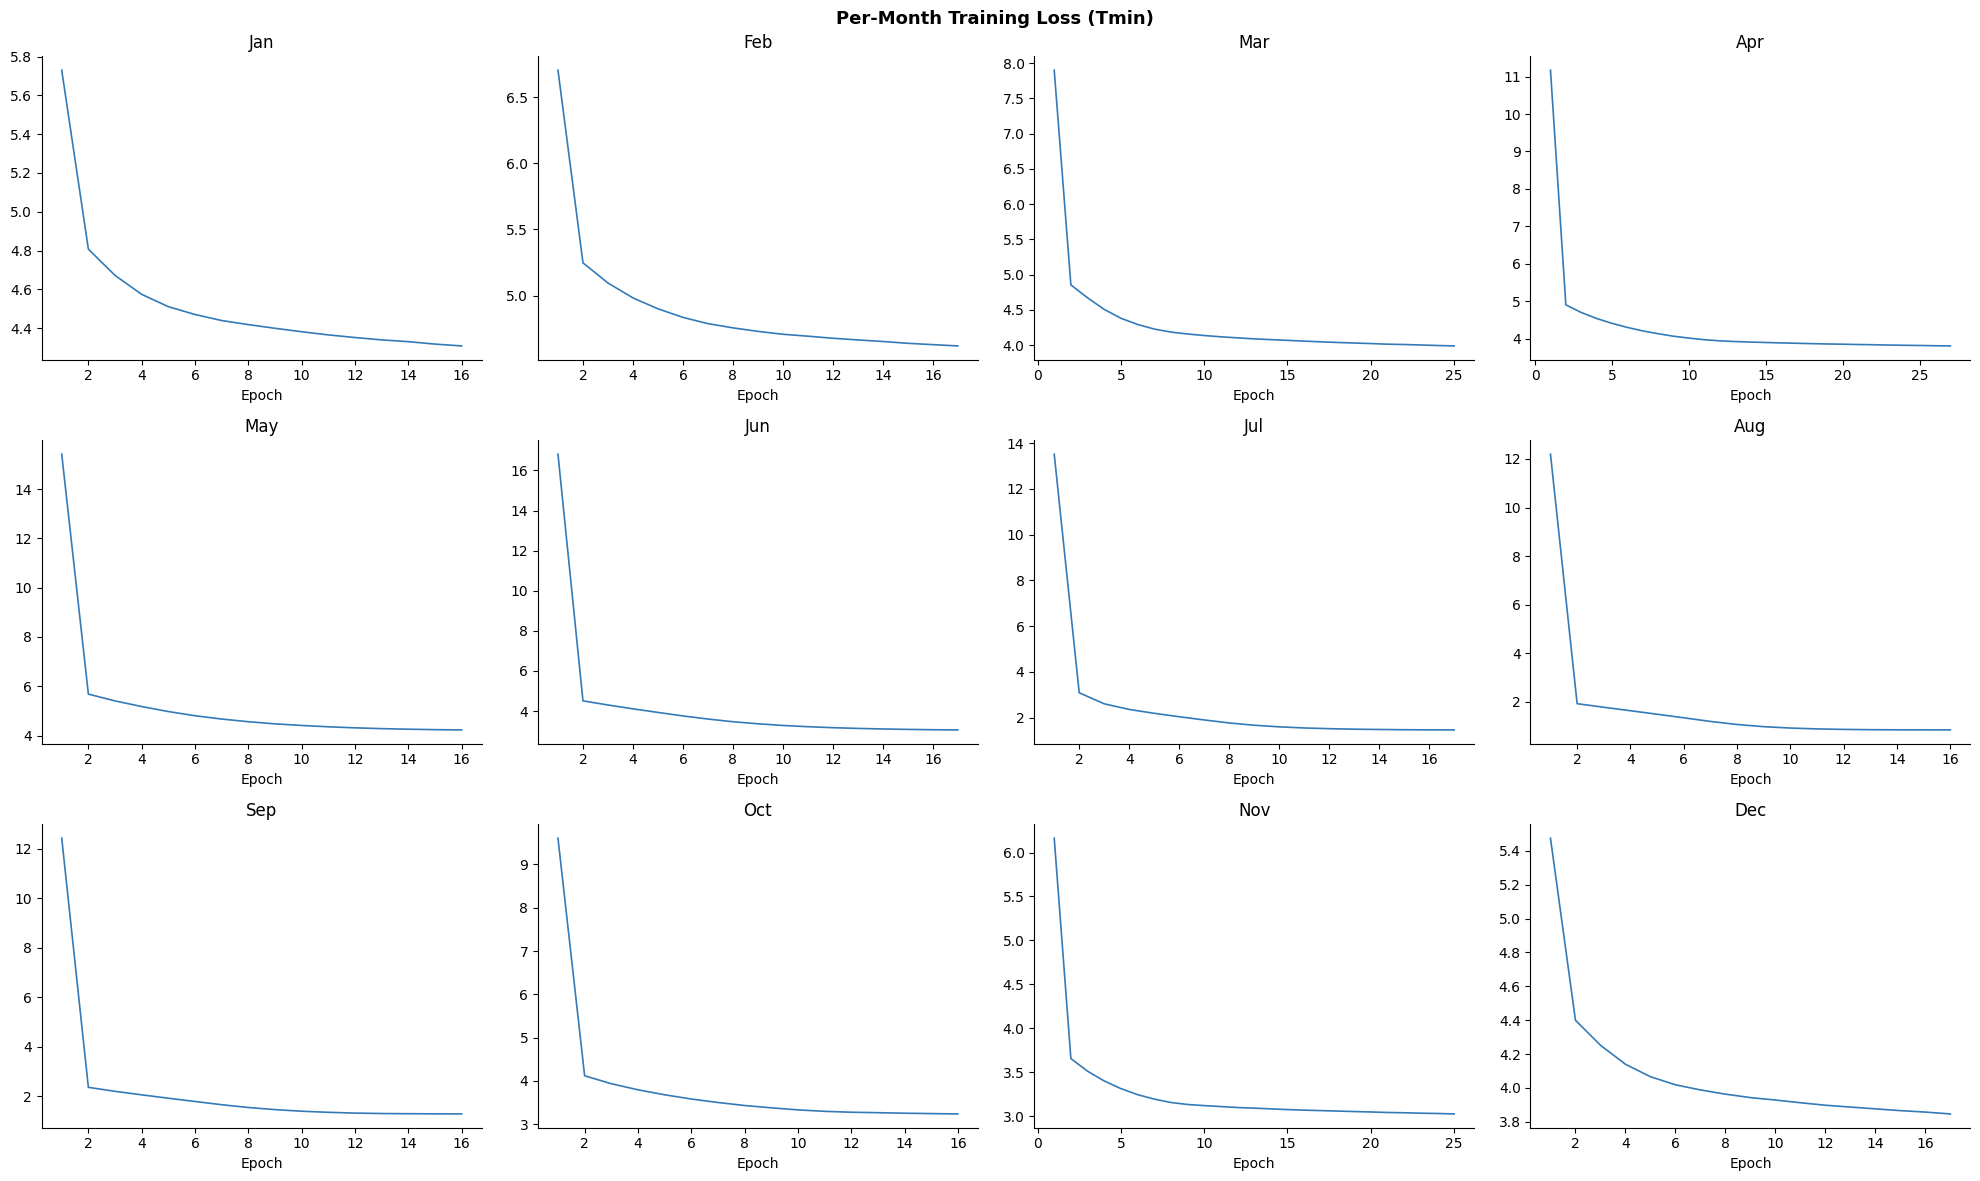

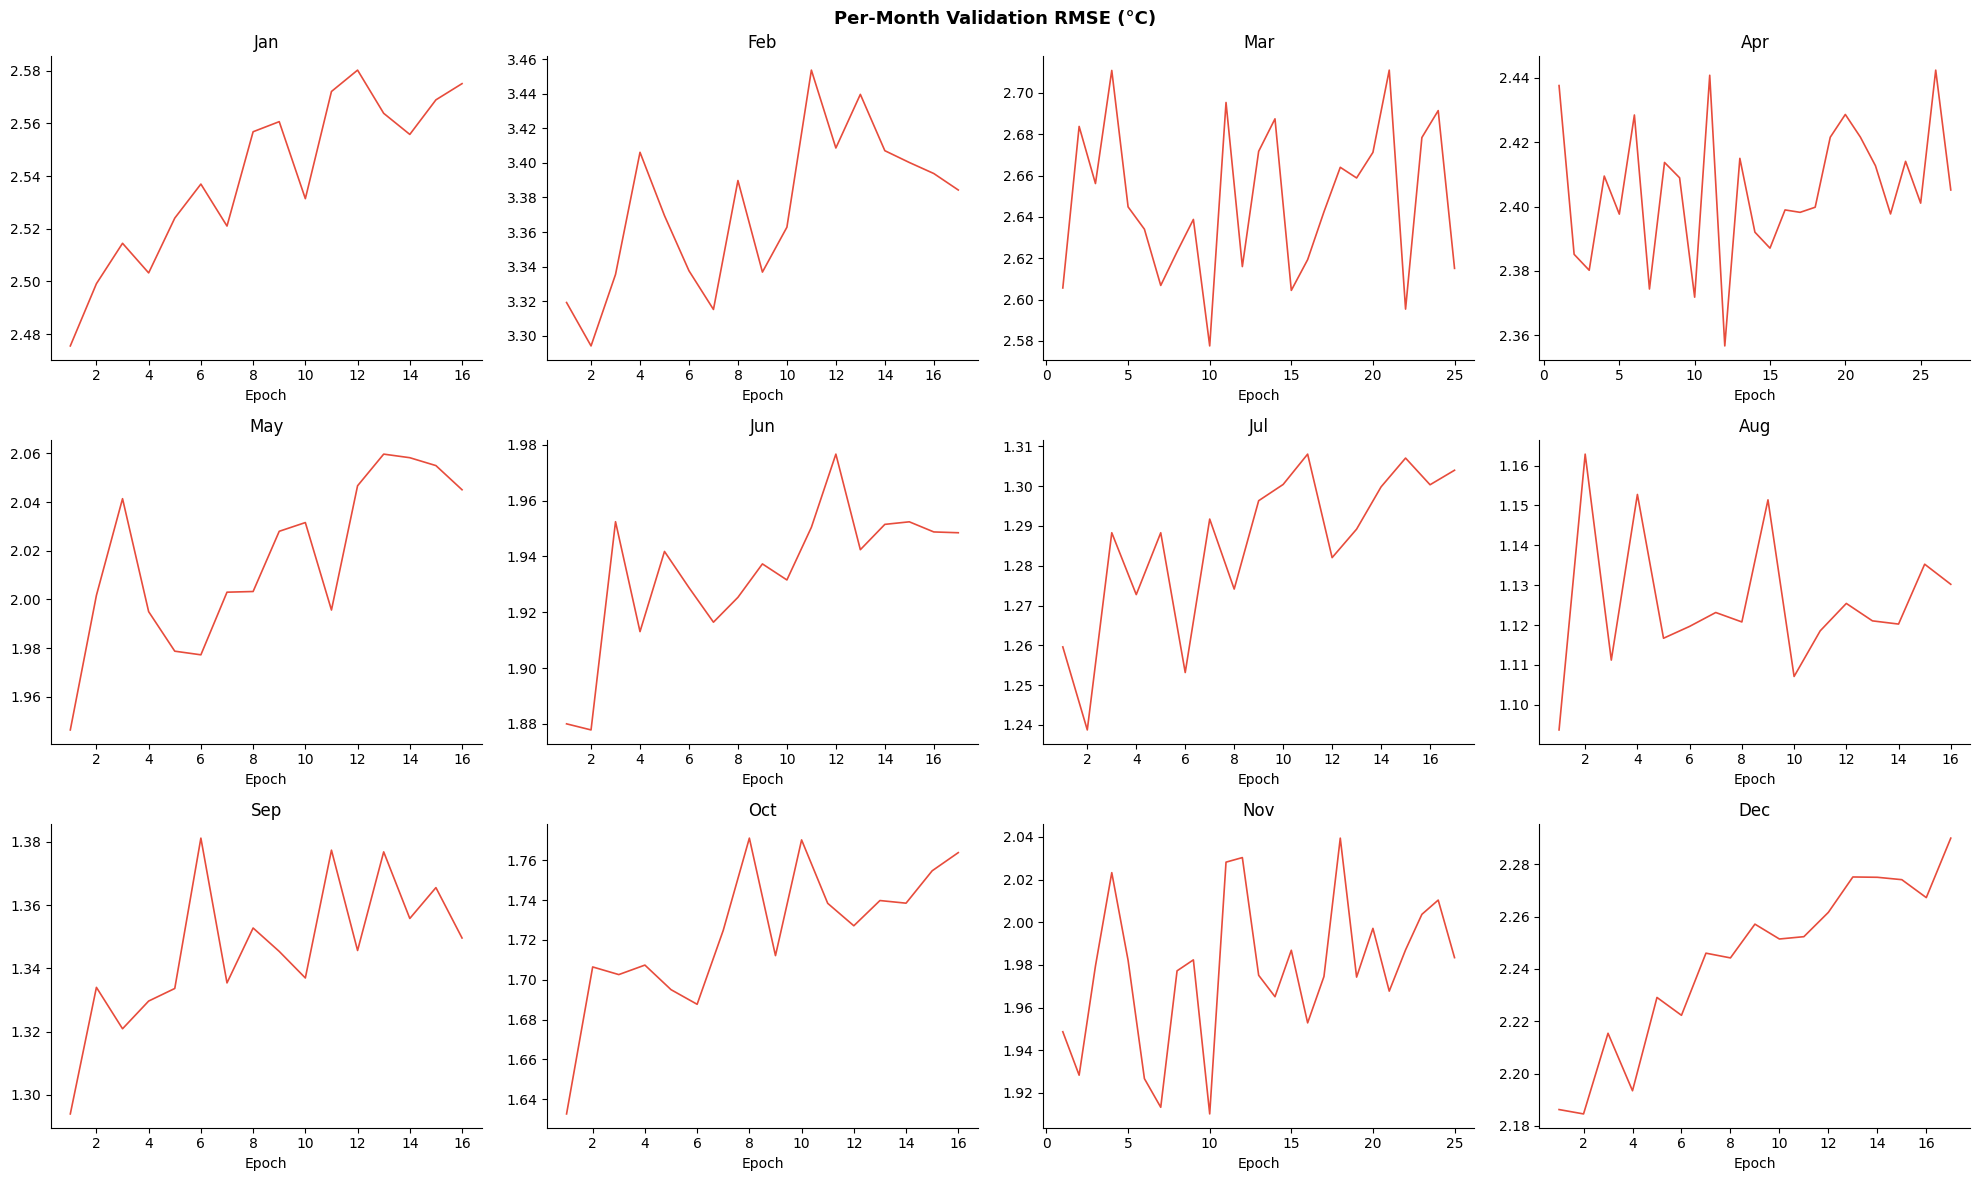

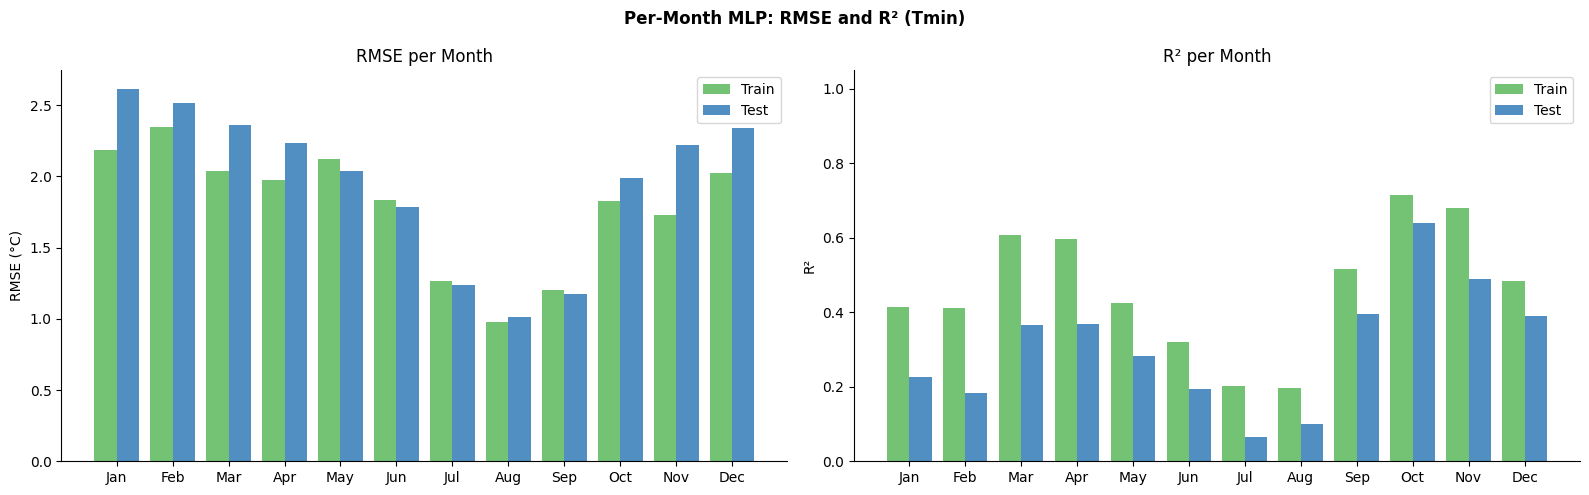


  COMPLETE → /kaggle/working/tmin_downscaling_output


In [11]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 5 — QUICK EVALUATION  (pooled metrics + plots)                ║
# ║  Same as precip except: no y>=0 filter, units=°C                    ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("\n" + "="*60 + "\n  EVALUATION\n" + "="*60)
def kge(o, s):
    v = np.isfinite(o) & np.isfinite(s); o, s = o[v], s[v]
    if len(o) < 2: return np.nan
    r = np.corrcoef(o, s)[0, 1]
    return 1 - np.sqrt((r-1)**2 + (np.std(s)/(np.std(o)+1e-10)-1)**2
                       + (np.mean(s)/(np.mean(o)+1e-10)-1)**2)

def evaluate(bc_nc, years, label):
    ds = xr.open_dataset(bc_nc); obs_f, prd_f = [], []
    cell_rmse = []
    for month in range(1, 13):
        obs = load_obs_month(years, month)
        da  = ds[VAR_NAME].sel(time=ds[VAR_NAME].time.dt.month == month)
        if obs is None or len(da.time) == 0: continue
        nn_ = min(len(obs), len(da.time))
        o2 = obs[:nn_]; p2 = da.values[:nn_, ii_loc, jj_loc]
        obs_f.append(o2.ravel()); prd_f.append(p2.ravel())
        with np.errstate(invalid="ignore"):
            d = o2 - p2
            cell_rmse.append(np.sqrt(np.nanmean(d**2, axis=0)))
    ds.close()
    of = np.concatenate(obs_f); pf = np.concatenate(prd_f)
    v  = np.isfinite(of) & np.isfinite(pf)                    # ← NO >=0 filter
    cell_rmse = np.nanmean(np.vstack(cell_rmse), axis=0)
    print(f"\n  {label}\n  " + "─"*44)
    print(f"  N (pooled)        = {int(v.sum()):,}")
    print(f"  MAE  (pooled)     = {mean_absolute_error(of[v], pf[v]):.4f} {UNITS}")
    print(f"  RMSE (pooled)     = {np.sqrt(mean_squared_error(of[v], pf[v])):.4f} {UNITS}")
    print(f"  RMSE (cell-mean)  = {np.nanmean(cell_rmse):.4f} {UNITS}   ← honest spatial skill")
    print(f"  R²   (pooled)     = {r2_score(of[v], pf[v]):.4f}")
    print(f"  KGE  (pooled)     = {kge(of[v], pf[v]):.4f}", flush=True)

evaluate(BC_DAILY_TR, range(TRAIN_START, TRAIN_END+1), f"Training ({TRAIN_START}-{TRAIN_END})")
evaluate(BC_DAILY_TE, range(TEST_START,  TEST_END +1), f"Testing  ({TEST_START}-{TEST_END})")

# ════════════════════════ PLOTS ═══════════════════════════════════════
def grid_plot(key, title, color, fname):
    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes = axes.ravel()
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes[m-1]
        if m in epoch_metrics and epoch_metrics[m].get(key):
            ax.plot(range(1, len(epoch_metrics[m][key])+1), epoch_metrics[m][key],
                    color=color, lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}", dpi=150, bbox_inches="tight"); plt.show()

grid_plot("train_loss", f"Per-Month Training Loss ({VAR_LABEL})", "#337ab7", "loss_curves.png")
grid_plot("val_rmse",   f"Per-Month Validation RMSE ({UNITS})", "#e74c3c", "val_rmse_curves.png")

months = [m for m in range(1, 13) if m in train_summary]
if months:
    x, w = np.arange(len(months)), 0.4
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"Per-Month MLP: RMSE and R² ({VAR_LABEL})", fontsize=12, fontweight="bold")
    for ax, i_tr, i_te, ylab, ttl, ylim in [
        (ax1, 0, 2, f"RMSE ({UNITS})", "RMSE per Month", None),
        (ax2, 1, 3, "R²",              "R² per Month",   (0, 1.05))]:
        ax.bar(x-w/2, [train_summary[m][i_tr] for m in months], w, label="Train", color="#5cb85c", alpha=.85)
        ax.bar(x+w/2, [train_summary[m][i_te] for m in months], w, label="Test",  color="#337ab7", alpha=.85)
        ax.set_xticks(x); ax.set_xticklabels([MONTH_NAMES[m-1] for m in months])
        ax.set_ylabel(ylab); ax.set_title(ttl)
        if ylim: ax.set_ylim(*ylim)
        ax.legend(); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/permonth_metrics.png", dpi=150, bbox_inches="tight"); plt.show()

print("\n" + "="*60 + f"\n  COMPLETE → {OUT_DIR}\n" + "="*60)

Computing all metrics in single low-RAM pass …
  Jan ✓    Feb ✓    Mar ✓    Apr ✓    May ✓    Jun ✓    Jul ✓    Aug ✓    Sep ✓    Oct ✓    Nov ✓    Dec ✓  
✓ single-pass collection done


  METRICS TABLE — Tmin  (test 2008–2014)
Metric                                             Raw GCM      MLP downscaled   QM Bias-corrected
--------------------------------------------------------------------------------------------------

── MONTHLY ──────────────────────────────────────────────────────────
  Monthly RMSE Jan   (per-cell→avg)    2.5592    1.3342    1.3611
  Monthly RMSE Feb   (per-cell→avg)    2.4081    1.2658    1.3071
  Monthly RMSE Mar   (per-cell→avg)    3.4441    1.3637    1.3690
  Monthly RMSE Apr   (per-cell→avg)    3.1559    1.1104    1.1344
  Monthly RMSE May   (per-cell→avg)    3.2730    0.9608    0.9542
  Monthly RMSE Jun   (per-cell→avg)    3.4182    0.7324    0.8602
  Monthly RMSE Jul   (per-cell→avg)    4.3090    0.5877    0.6435
  Monthly RMSE Aug   (per-cell→avg)    3

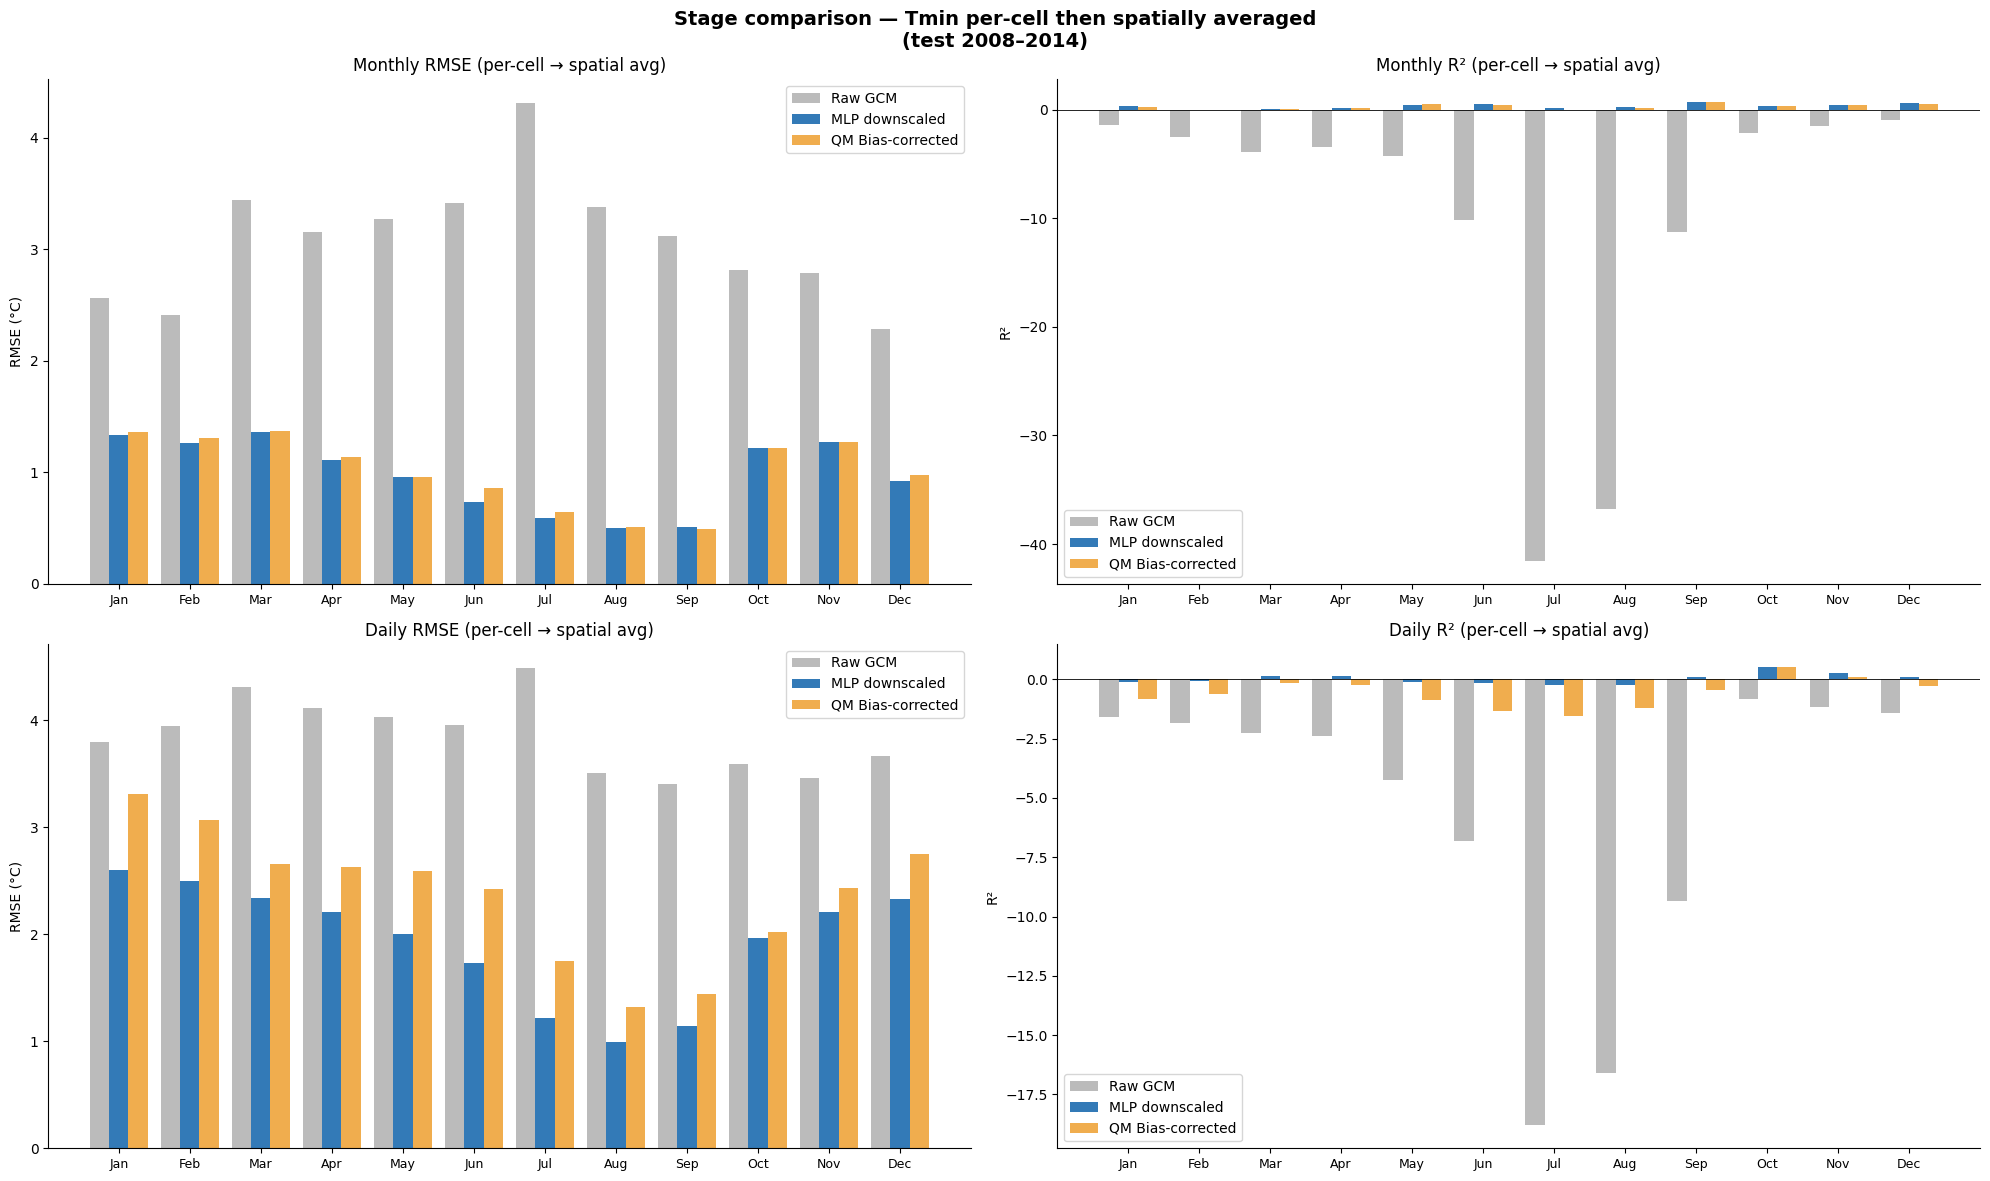

✅ Saved → stage_bars_percell_avg.png


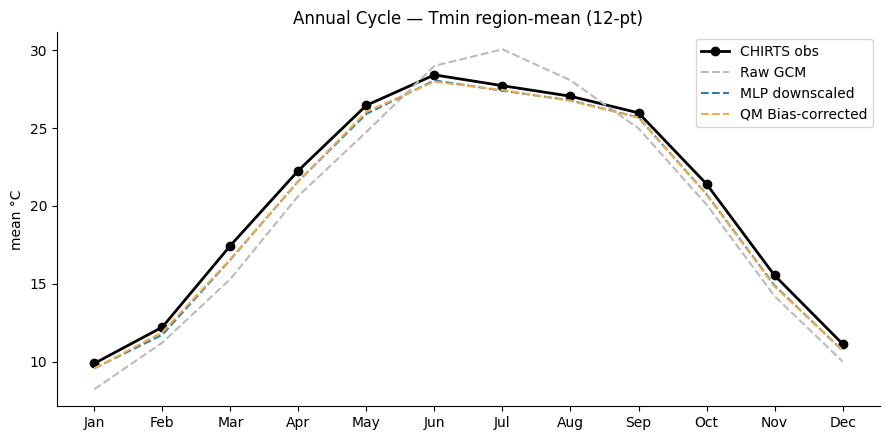

✅ Saved → annual_cycle.png


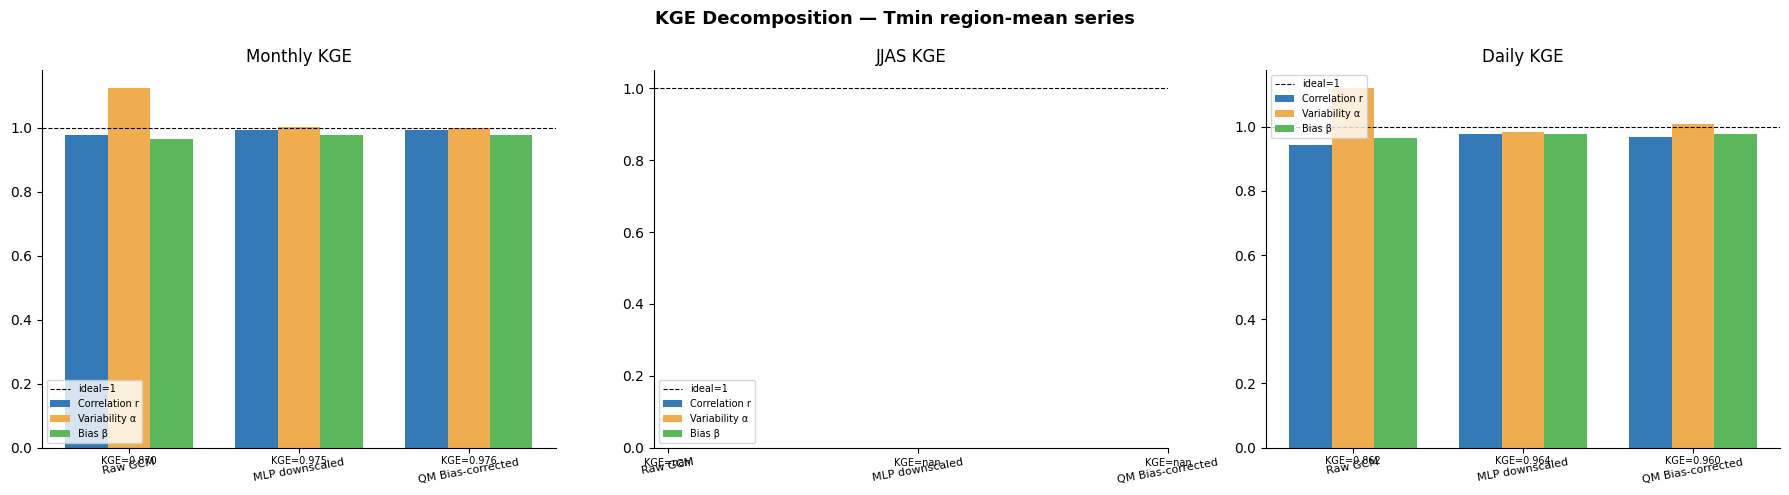

✅ Saved → kge_decomposition.png


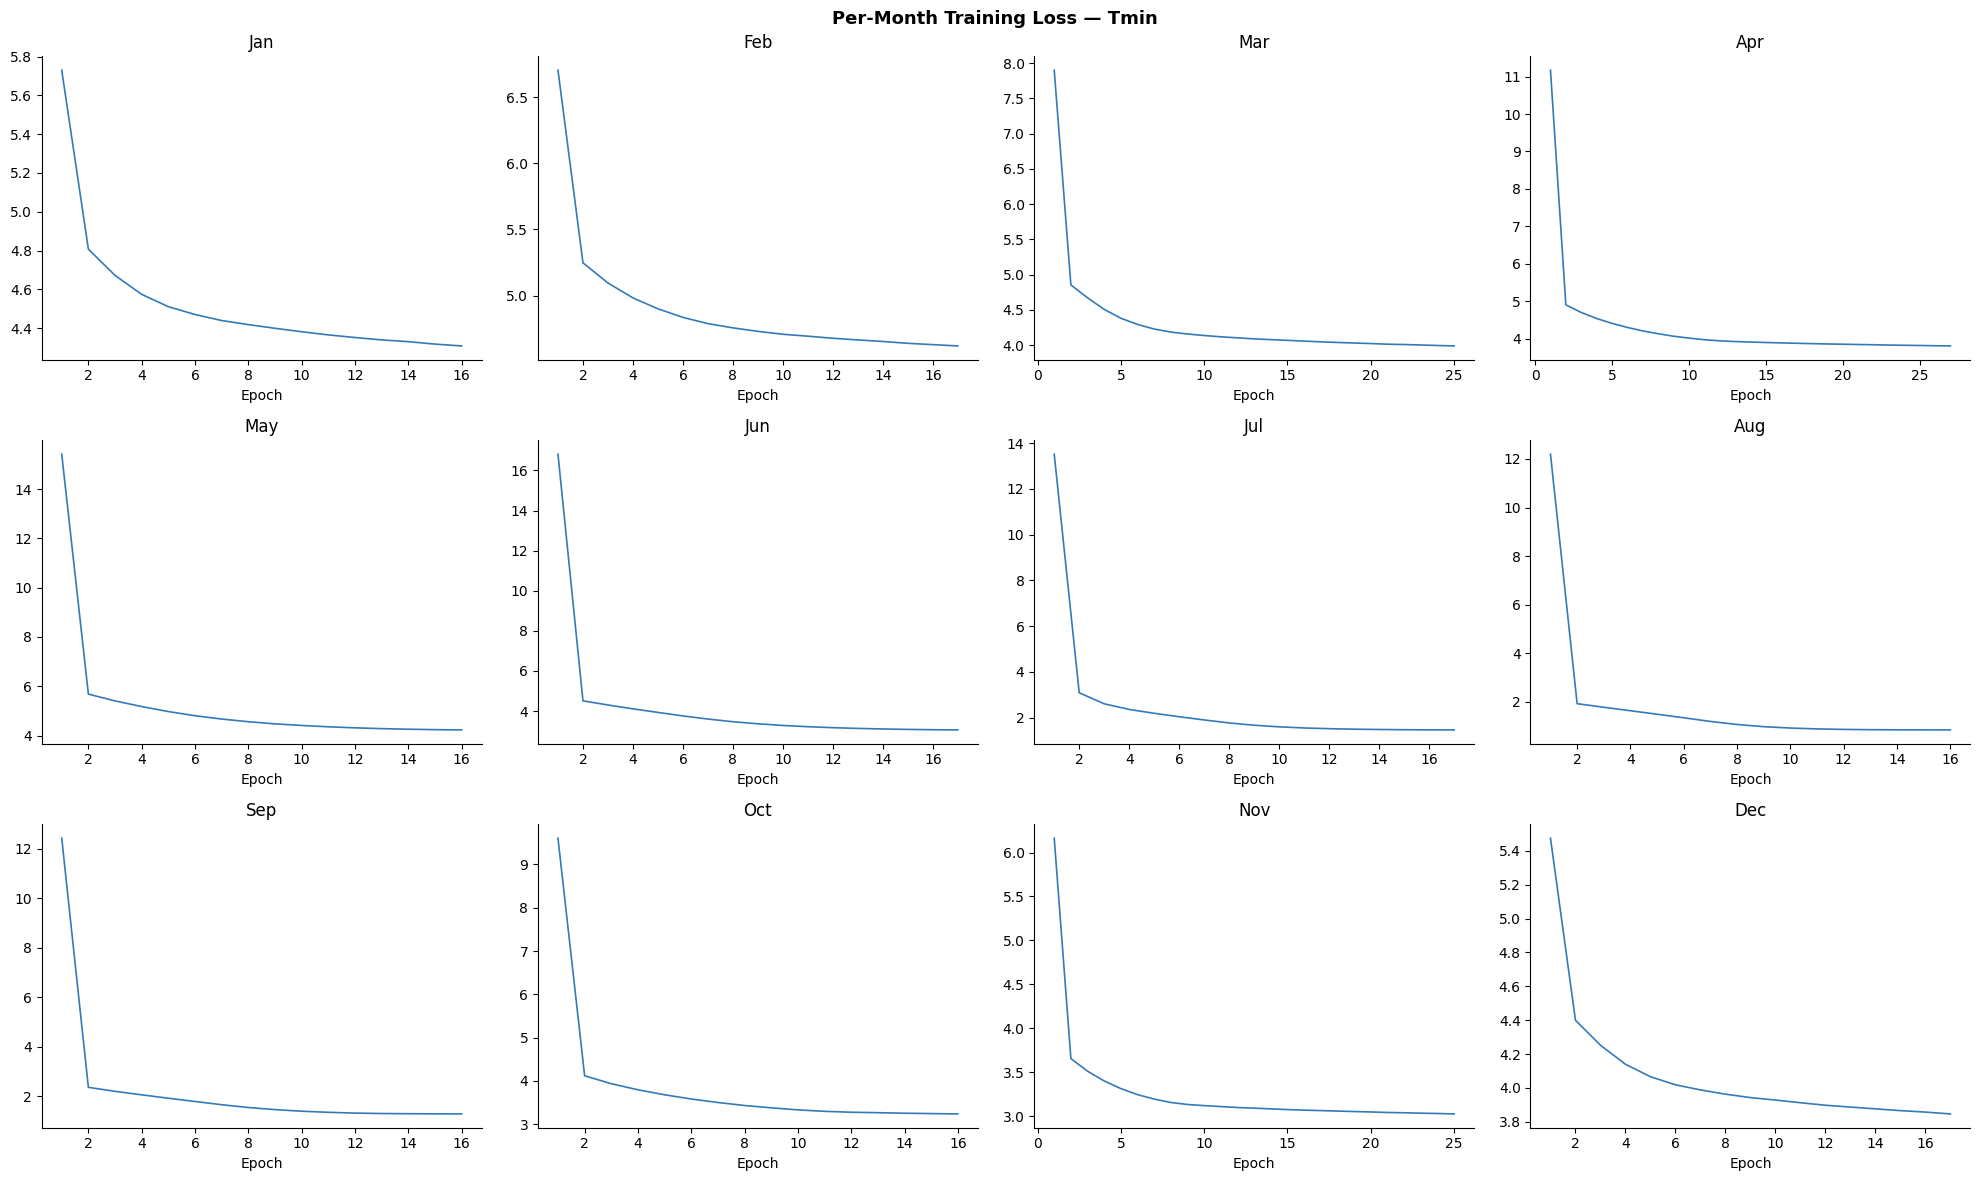

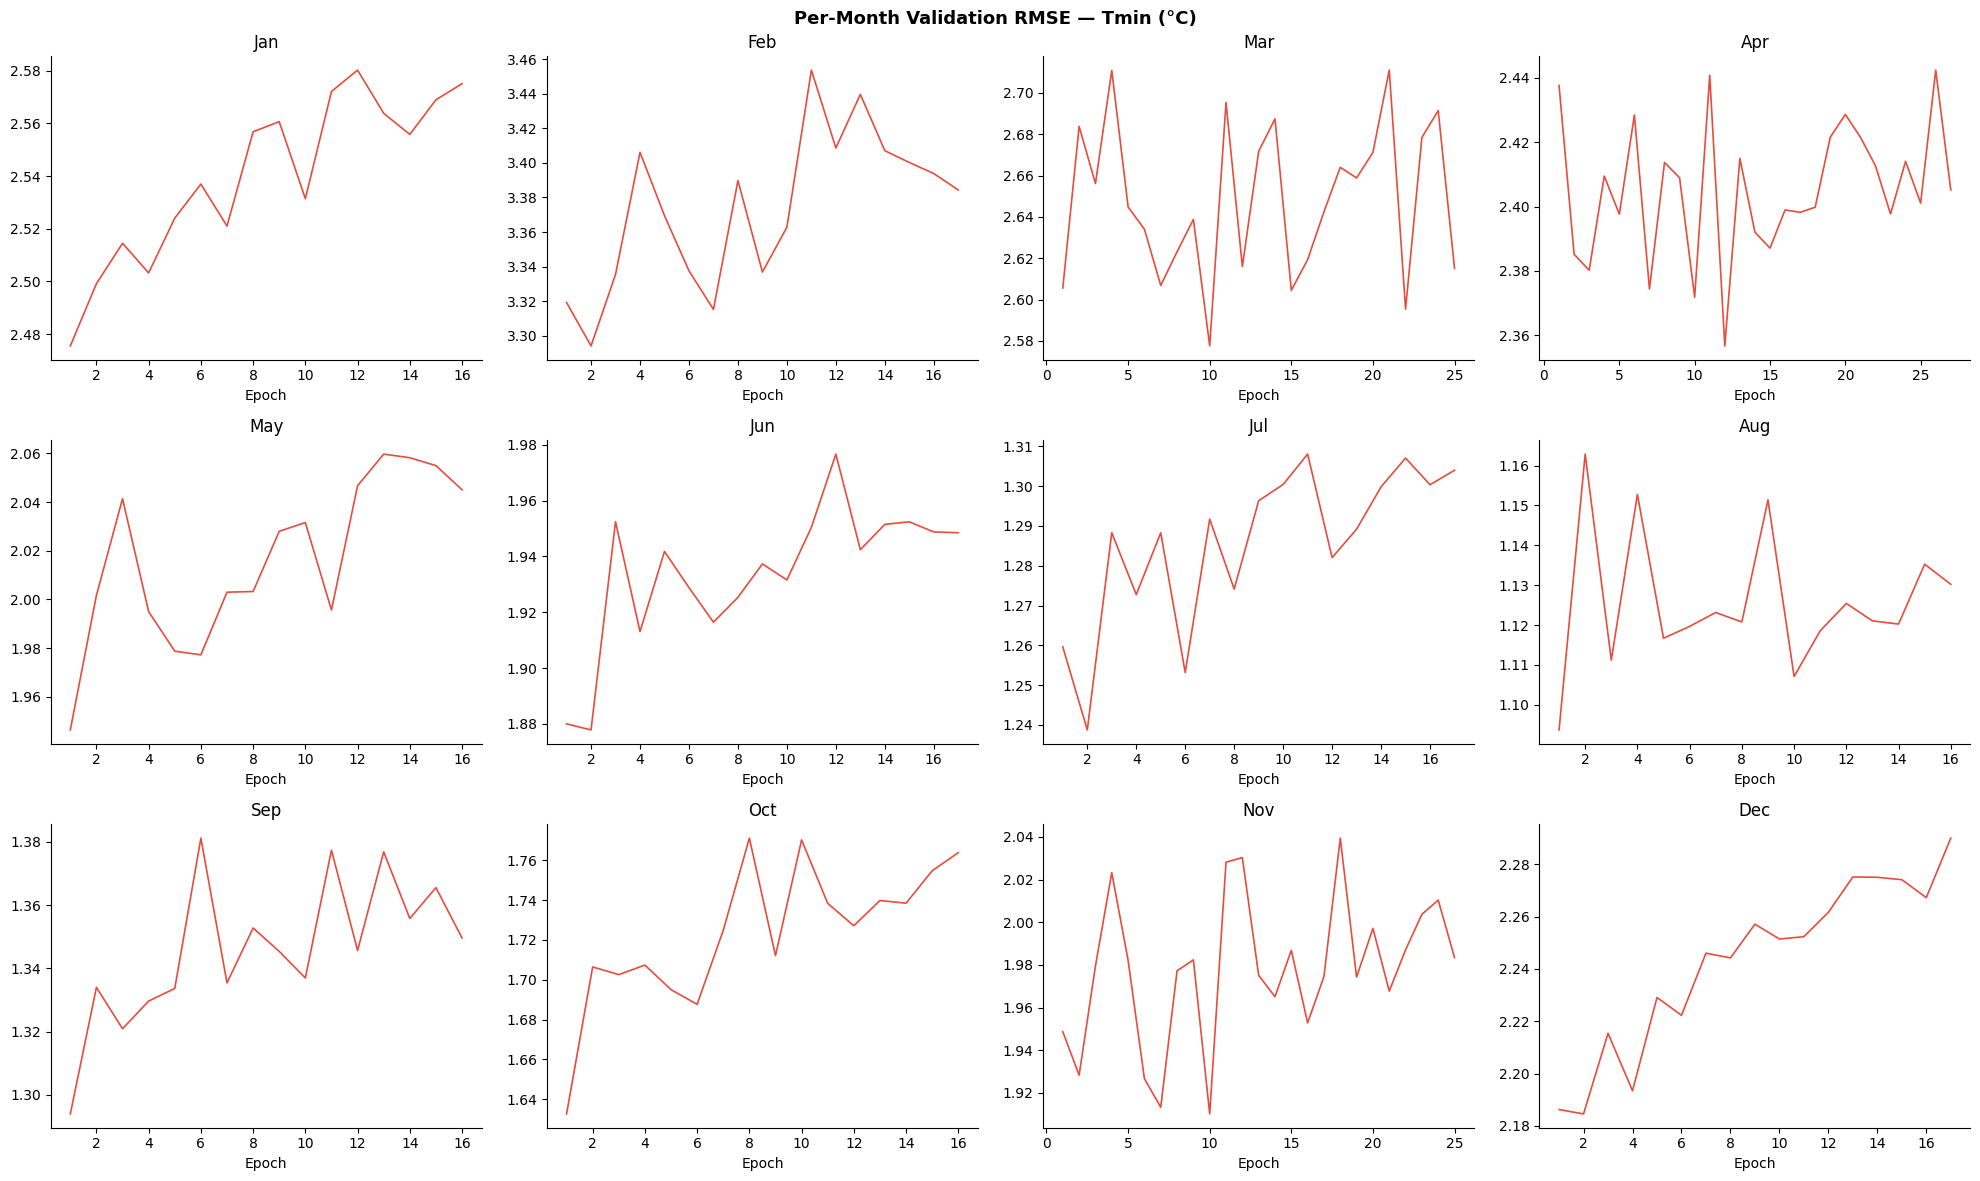

✅ Saved → loss_curves.png, val_rmse_curves.png


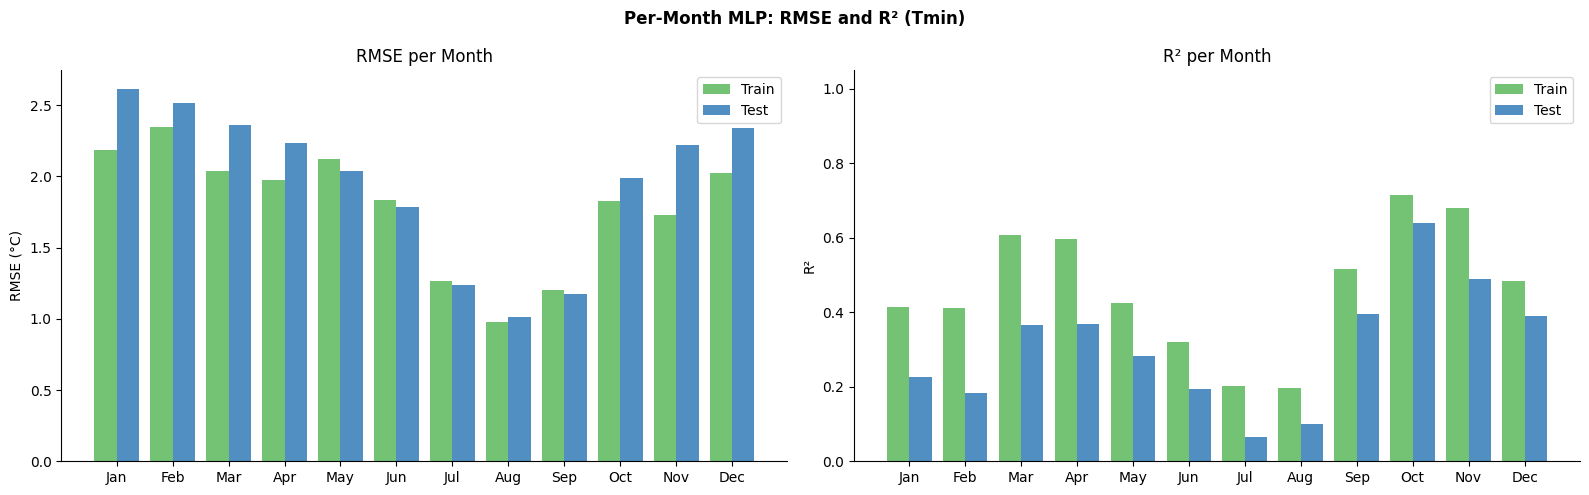

✅ Saved → permonth_metrics.png

✅ All metrics saved → /kaggle/working/tmin_downscaling_output/metrics_revised_tmin.csv
✅ Revised evaluation complete.


In [12]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 6 — DETAILED EVALUATION (low-RAM)                             ║
# ║  Same structure as precip except:                                    ║
# ║    • monthly totals → nanMEAN (avg temp, not sum)                   ║
# ║    • no >=0 filter on obs/preds                                      ║
# ║    • units = °C throughout                                           ║
# ╚══════════════════════════════════════════════════════════════════════╝
import os, gc
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

gc.collect()

# ── reload QM TFs if needed ─────────────────────────────────────────────
if "tf_store" not in globals() or not tf_store:
    if os.path.exists(QM_TF_PATH):
        with np.load(QM_TF_PATH) as z:
            tf_store = {k: z[k] for k in z.files}
        print(f"✅ Loaded QM transfer functions for {len(tf_store)//2} month(s)")
    else:
        raise FileNotFoundError(f"QM transfer file not found: {QM_TF_PATH}")

EVAL_YEARS  = range(TEST_START, TEST_END + 1)
EVAL_NC_MLP = MLP_DAILY_TE
EVAL_NC_BC  = BC_DAILY_TE

STAGES = ["raw", "mlp", "bias"]
LABELS = {"raw": "Raw GCM", "mlp": "MLP downscaled", "bias": "QM Bias-corrected"}
COLORS = {"raw": "#bbbbbb", "mlp": "#337ab7", "bias": "#f0ad4e"}

# ── metric helpers ───────────────────────────────────────────────────────
def _rmse_e(o, p): return float(np.sqrt(np.nanmean((o - p) ** 2)))
def _r2_e(o, p):
    ss = np.nansum((o - np.nanmean(o)) ** 2)
    return float(1 - np.nansum((o - p) ** 2) / ss) if ss > 0 else np.nan
def _corr_e(o, p):
    if o.size < 2 or np.nanstd(o) == 0 or np.nanstd(p) == 0: return np.nan
    return float(np.corrcoef(o, p)[0, 1])
def _kge_components_e(o, p):
    if o.size < 2: return np.nan, np.nan, np.nan, np.nan
    r = _corr_e(o, p)
    a = float(np.nanstd(p) / np.nanstd(o)) if np.nanstd(o) > 0 else np.nan
    b = float(np.nanmean(p) / np.nanmean(o)) if np.nanmean(o) != 0 else np.nan
    if any(np.isnan(v) for v in [r, a, b]): return np.nan, r, a, b
    kge = float(1 - np.sqrt((r - 1)**2 + (a - 1)**2 + (b - 1)**2))
    return kge, r, a, b

# ════════════════════════════════════════════════════════════════════════════
#  SINGLE PASS
# ════════════════════════════════════════════════════════════════════════════
print("Computing all metrics in single low-RAM pass …", flush=True)

monthly_rmse   = {s: np.full(12, np.nan) for s in STAGES}
monthly_r2     = {s: np.full(12, np.nan) for s in STAGES}
daily_rmse     = {s: np.full(12, np.nan) for s in STAGES}
daily_r2       = {s: np.full(12, np.nan) for s in STAGES}
clim_sum       = {s: np.zeros(n_region)  for s in STAGES}
obs_clim_sum   = np.zeros(n_region)
reg_mon_sum    = {s: np.zeros(12) for s in STAGES}
obs_reg_mon_sum = np.zeros(12)
reg_mon_cnt    = np.zeros(12)
total_days     = 0

mon_series     = {s: [] for s in STAGES}
obs_mon_list   = []
daily_reg_series = {s: [] for s in STAGES}
obs_daily_reg    = []

obs_clim_maps  = {}
pred_clim_maps = {s: {} for s in STAGES}

dsm = xr.open_dataset(EVAL_NC_MLP)
dsb = xr.open_dataset(EVAL_NC_BC)

for month in range(1, 13):
    g, doy, dates = load_gcm_month(list(EVAL_YEARS), month)
    obs           = load_obs_month(list(EVAL_YEARS), month)
    if g is None or obs is None:
        print(f"  {MONTH_NAMES[month-1]}: skip", flush=True); continue

    da_mlp = dsm[VAR_NAME].sel(time=dsm[VAR_NAME].time.dt.month == month)
    da_bc  = dsb[VAR_NAME].sel(time=dsb[VAR_NAME].time.dt.month == month)
    n = min(len(g), len(obs), len(da_mlp.time), len(da_bc.time))

    raw   = g[:n]
    mlp   = da_mlp.values[:n, ii_loc, jj_loc]
    bias  = da_bc.values[:n, ii_loc, jj_loc]
    obs_n = obs[:n]
    yrs   = dates[:n].year.values
    preds = {"raw": raw, "mlp": mlp, "bias": bias}

    obs_v = np.where(np.isfinite(obs_n), obs_n, np.nan)         # ← NO >=0 filter

    # ── DAILY per-cell metrics  (VECTORIZED — identical to per-cell loop) ──
    for s in STAGES:
        p_v = np.where(np.isfinite(preds[s]), preds[s], np.nan) # ← NO >=0 filter
        m_dc = np.isfinite(obs_v) & np.isfinite(p_v)            # joint finite mask (days×cells)
        O = np.where(m_dc, obs_v, np.nan); P = np.where(m_dc, p_v, np.nan)
        keep = m_dc.sum(axis=0) >= 2                            # replicate '<2 skip'
        if keep.any():
            with np.errstate(invalid="ignore", divide="ignore"):
                diff2  = (O - P) ** 2
                rmse_c = np.sqrt(np.nanmean(diff2, axis=0))
                Omean  = np.nanmean(O, axis=0)
                ss_res = np.nansum(diff2, axis=0)
                ss_tot = np.nansum((O - Omean) ** 2, axis=0)
                r2_c   = np.where(ss_tot > 0, 1 - ss_res / ss_tot, np.nan)
            daily_rmse[s][month-1] = float(np.nanmean(rmse_c[keep]))
            daily_r2[s][month-1]   = float(np.nanmean(r2_c[keep]))

    # ── MONTHLY metrics (per-year MEAN → per-cell metric → avg) ──────
    # ★ KEY CHANGE: nanmean instead of nansum (avg temperature, not total)
    uy = np.unique(yrs)
    with np.errstate(invalid="ignore", divide="ignore"):
        oavg = np.stack([np.nanmean(obs_n[yrs == yr], axis=0) for yr in uy])   # (Y, cells)
        for s in STAGES:
            pavg = np.stack([np.nanmean(preds[s][yrs == yr], axis=0) for yr in uy])
            vv   = np.isfinite(oavg) & np.isfinite(pavg)
            OA = np.where(vv, oavg, np.nan); PA = np.where(vv, pavg, np.nan)
            keep = vv.sum(axis=1) > 0                           # replicate 'if vv.sum()==0: continue'
            if keep.any():
                diff2  = (OA - PA) ** 2
                rmse_y = np.sqrt(np.nanmean(diff2, axis=1))
                Omean  = np.nanmean(OA, axis=1, keepdims=True)
                ss_res = np.nansum(diff2, axis=1)
                ss_tot = np.nansum((OA - Omean) ** 2, axis=1)
                r2_y   = np.where(ss_tot > 0, 1 - ss_res / ss_tot, np.nan)
                monthly_rmse[s][month-1] = float(np.nanmean(rmse_y[keep]))
                monthly_r2[s][month-1]   = float(np.nanmean(r2_y[keep]))

    # ── region-mean monthly series (for KGE) ─
    for yr in np.unique(yrs):
        sel = yrs == yr
        obs_mon_list.append(float(np.nanmean(np.nanmean(obs_n[sel], axis=0))))  # mean/time → mean/cells
        for s in STAGES:
            mon_series[s].append(float(np.nanmean(np.nanmean(preds[s][sel], axis=0))))

    # ── region-mean daily series ──
    obs_daily_reg.append(np.nanmean(obs_v, axis=1))
    for s in STAGES:
        daily_reg_series[s].append(np.nanmean(
            np.where(np.isfinite(preds[s]), preds[s], np.nan), axis=1))

    # ── climatology ──
    obs_clim_sum += np.nansum(obs_v, axis=0)
    total_days   += n
    for s in STAGES:
        clim_sum[s] += np.nansum(
            np.where(np.isfinite(preds[s]), preds[s], np.nan), axis=0)

    obs_clim_maps[month] = np.nanmean(obs_v, axis=0)
    for s in STAGES:
        pred_clim_maps[s][month] = np.nanmean(
            np.where(np.isfinite(preds[s]), preds[s], np.nan), axis=0)

    # ── annual cycle ──
    obs_reg_mon_sum[month-1] += float(np.nanmean(obs_v))
    reg_mon_cnt[month-1]     += 1
    for s in STAGES:
        reg_mon_sum[s][month-1] += float(
            np.nanmean(np.where(np.isfinite(preds[s]), preds[s], np.nan)))

    del raw, mlp, bias, obs_n, obs_v, preds, da_mlp, da_bc
    gc.collect()
    print(f"  {MONTH_NAMES[month-1]} ✓", end="  ", flush=True)

dsm.close(); dsb.close(); gc.collect()
print("\n✓ single-pass collection done\n")

# ── derived scalars ──────────────────────────────────────────────────────
obs_clim     = obs_clim_sum / max(total_days, 1)
clim_percell = {s: clim_sum[s] / max(total_days, 1) for s in STAGES}
cnt = np.where(reg_mon_cnt == 0, 1, reg_mon_cnt)
obs_reg_mon  = obs_reg_mon_sum / cnt
reg_mon_mean = {s: reg_mon_sum[s] / cnt for s in STAGES}

obs_mon_arr = np.array(obs_mon_list)
monthly_kge = {}
for s in STAGES:
    kge, r, a, b = _kge_components_e(obs_mon_arr, np.array(mon_series[s]))
    monthly_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}

valid_months = sorted(obs_clim_maps.keys())
spatial_clim_corr = {}
for s in STAGES:
    p_vec = np.concatenate([pred_clim_maps[s][m] for m in valid_months if m in pred_clim_maps[s]])
    o_vec = np.concatenate([obs_clim_maps[m] for m in valid_months if m in pred_clim_maps[s]])
    v = np.isfinite(o_vec) & np.isfinite(p_vec)
    spatial_clim_corr[s] = _corr_e(o_vec[v], p_vec[v])

annual_cycle_corr = {s: _corr_e(obs_reg_mon, reg_mon_mean[s]) for s in STAGES}

annual_pattern_corr = {}
v_ap = np.isfinite(obs_clim)
for s in STAGES:
    vv = v_ap & np.isfinite(clim_percell[s])
    annual_pattern_corr[s] = _corr_e(obs_clim[vv], clim_percell[s][vv])

# JJAS KGE & R²
jjas_idx = []
k = 0
for month in range(1, 13):
    g, _, _ = load_gcm_month(list(EVAL_YEARS), month)
    obs     = load_obs_month(list(EVAL_YEARS), month)
    if g is None or obs is None: continue
    n2 = min(len(g), len(obs))
    if month in [6, 7, 8, 9]:
        jjas_idx.extend(range(k, k + n2))
    k += n2

jjas_kge, jjas_r2 = {}, {}
for s in STAGES:
    ms = np.array(mon_series[s])
    if not jjas_idx or len(ms) == 0:
        jjas_kge[s] = {"KGE": np.nan, "r": np.nan, "alpha": np.nan, "beta": np.nan}
        jjas_r2[s] = np.nan; continue
    vi = [i for i in jjas_idx if i < len(ms) and i < len(obs_mon_arr)]
    o_j, p_j = obs_mon_arr[vi], ms[vi]
    vm = np.isfinite(o_j) & np.isfinite(p_j)
    kge, r, a, b = _kge_components_e(o_j[vm], p_j[vm])
    jjas_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}
    jjas_r2[s] = _r2_e(o_j[vm], p_j[vm])

obs_d = np.concatenate(obs_daily_reg)
daily_kge = {}
for s in STAGES:
    pd_arr = np.concatenate(daily_reg_series[s])
    kge, r, a, b = _kge_components_e(obs_d, pd_arr)
    daily_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}

# ════════════════════════════════════════════════════════════════════════════
# PRINT FULL METRICS TABLE
# ════════════════════════════════════════════════════════════════════════════
yr0, yr1 = EVAL_YEARS.start, EVAL_YEARS.stop - 1
print(f"\n{'='*72}")
print(f"  METRICS TABLE — {VAR_LABEL}  (test {yr0}–{yr1})")
print(f"{'='*72}")

def _fmt(v): return f"{v:8.4f}" if np.isfinite(v) else "     nan"

header = f"{'Metric':<38}" + "".join(f"  {LABELS[s]:>18}" for s in STAGES)
print(header); print("-"*len(header))

print("\n── MONTHLY ──────────────────────────────────────────────────────────")
for m in range(1, 13):
    print(f"  Monthly RMSE {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(monthly_rmse[s][m-1]) for s in STAGES]))
for m in range(1, 13):
    print(f"  Monthly R²   {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(monthly_r2[s][m-1]) for s in STAGES]))
print(f"\n  {'Metric':<38}" + "".join(f"  {LABELS[s]:>18}" for s in STAGES))
print("  " + "-"*78)
for key in ["KGE", "r", "alpha", "beta"]:
    row = [monthly_kge[s][key] for s in STAGES]
    print(f"  Monthly {key:<30}" + "".join([f"  {_fmt(v):>18}" for v in row]))

print("\n── SPATIAL & ANNUAL CYCLE ────────────────────────────────────────────")
print(f"  {'Spatial Climatology Corr (12 maps)':<38}" +
      "".join(f"  {_fmt(spatial_clim_corr[s]):>18}" for s in STAGES))
print(f"  {'Annual Cycle Corr (12-pt region mean)':<38}" +
      "".join(f"  {_fmt(annual_cycle_corr[s]):>18}" for s in STAGES))
print(f"  {'Annual Pattern Corr (per-cell mean)':<38}" +
      "".join(f"  {_fmt(annual_pattern_corr[s]):>18}" for s in STAGES))

print("\n── JJAS ──────────────────────────────────────────────────────────────")
for key in ["KGE", "r", "alpha", "beta"]:
    row = [jjas_kge[s][key] for s in STAGES]
    print(f"  JJAS {key:<33}" + "".join([f"  {_fmt(v):>18}" for v in row]))
print(f"  {'JJAS R² (region-mean series)':<38}" +
      "".join(f"  {_fmt(jjas_r2[s]):>18}" for s in STAGES))

print("\n── DAILY ─────────────────────────────────────────────────────────────")
for m in range(1, 13):
    print(f"  Daily RMSE {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(daily_rmse[s][m-1]) for s in STAGES]))
for m in range(1, 13):
    print(f"  Daily R²   {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(daily_r2[s][m-1]) for s in STAGES]))
for key in ["KGE", "r", "alpha", "beta"]:
    row = [daily_kge[s][key] for s in STAGES]
    print(f"  Daily {key:<33}" + "".join([f"  {_fmt(v):>18}" for v in row]))

# ════════════════════════════════════════════════════════════════════════════
# STAGE BAR CHARTS
# ════════════════════════════════════════════════════════════════════════════
x = np.arange(12); w = 0.27
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle(f"Stage comparison — {VAR_LABEL} per-cell then spatially averaged\n"
             f"(test {yr0}–{yr1})", fontsize=14, fontweight="bold")

ax = axes[0, 0]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, monthly_rmse[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Monthly RMSE (per-cell → spatial avg)"); ax.set_ylabel(f"RMSE ({UNITS})")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[0, 1]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, monthly_r2[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Monthly R² (per-cell → spatial avg)"); ax.set_ylabel("R²")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[1, 0]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, daily_rmse[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Daily RMSE (per-cell → spatial avg)"); ax.set_ylabel(f"RMSE ({UNITS})")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[1, 1]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, daily_r2[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Daily R² (per-cell → spatial avg)"); ax.set_ylabel("R²")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/stage_bars_percell_avg.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → stage_bars_percell_avg.png")

# ════════════════════════════════════════════════════════════════════════════
# ANNUAL CYCLE LINE PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, 13), obs_reg_mon, "k-o", lw=2, label="CHIRTS obs")
for s in STAGES:
    ax.plot(range(1, 13), reg_mon_mean[s], "--", color=COLORS[s], label=LABELS[s])
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel(f"mean {UNITS}"); ax.set_title(f"Annual Cycle — {VAR_LABEL} region-mean (12-pt)")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/annual_cycle.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → annual_cycle.png")

# ════════════════════════════════════════════════════════════════════════════
# KGE DECOMPOSITION
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"KGE Decomposition — {VAR_LABEL} region-mean series", fontsize=13, fontweight="bold")
kge_sets = [("Monthly KGE", monthly_kge), ("JJAS KGE", jjas_kge), ("Daily KGE", daily_kge)]
comp_labels = {"r": "Correlation r", "alpha": "Variability α", "beta": "Bias β"}
comp_colors = {"r": "#337ab7", "alpha": "#f0ad4e", "beta": "#5cb85c"}

for ax, (title, kge_dict) in zip(axes, kge_sets):
    xs = np.arange(len(STAGES)); bw = 0.25
    for j, comp in enumerate(["r", "alpha", "beta"]):
        vals = [kge_dict[s][comp] for s in STAGES]
        ax.bar(xs + (j-1)*bw, vals, bw, label=comp_labels[comp], color=comp_colors[comp])
    ax.axhline(1, color="k", lw=0.8, ls="--", label="ideal=1")
    ax.axhline(0, color="k", lw=0.4)
    ax.set_xticks(xs); ax.set_xticklabels([LABELS[s] for s in STAGES], fontsize=8, rotation=10)
    ax.set_title(title); ax.legend(fontsize=7)
    ax.spines[["top","right"]].set_visible(False)
    for j2, s in enumerate(STAGES):
        kge_v = kge_dict[s]["KGE"]
        ax.text(j2, ax.get_ylim()[0]*0.97 if ax.get_ylim()[0] < 0 else -0.05,
                f"KGE={kge_v:.3f}", ha="center", fontsize=7, color="black")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/kge_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → kge_decomposition.png")

# ════════════════════════════════════════════════════════════════════════════
# TRAINING CURVES
# ════════════════════════════════════════════════════════════════════════════
if "epoch_metrics" not in globals() or not epoch_metrics:
    epoch_metrics = {}
    for month in range(1, 13):
        mstr = f"m{month:02d}"
        ep_csv = os.path.join(OUT_DIR, f"epoch_metrics_{mstr}.csv")
        if os.path.exists(ep_csv):
            d = pd.read_csv(ep_csv)
            epoch_metrics[month] = {
                "train_loss": d["train_loss"].tolist(),
                "val_rmse":   d["val_rmse"].dropna().tolist(),
            }
    if epoch_metrics:
        print(f"✅ Loaded epoch metrics from CSV for {len(epoch_metrics)} month(s)")

if epoch_metrics:
    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes_flat = axes.ravel()
    fig.suptitle(f"Per-Month Training Loss — {VAR_LABEL}", fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes_flat[m-1]
        if m in epoch_metrics and epoch_metrics[m].get("train_loss"):
            vals = epoch_metrics[m]["train_loss"]
            ax.plot(range(1, len(vals)+1), vals, color="#337ab7", lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/loss_curves.png", dpi=150, bbox_inches="tight"); plt.show()

    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes_flat = axes.ravel()
    fig.suptitle(f"Per-Month Validation RMSE — {VAR_LABEL} ({UNITS})", fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes_flat[m-1]
        if m in epoch_metrics and epoch_metrics[m].get("val_rmse"):
            vals = epoch_metrics[m]["val_rmse"]
            ax.plot(range(1, len(vals)+1), vals, color="#e74c3c", lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/val_rmse_curves.png", dpi=150, bbox_inches="tight"); plt.show()
    print("✅ Saved → loss_curves.png, val_rmse_curves.png")

    if "train_summary" in globals() and train_summary:
        months = [m for m in range(1, 13) if m in train_summary]
        if months:
            x2, w2 = np.arange(len(months)), 0.4
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
            fig.suptitle(f"Per-Month MLP: RMSE and R² ({VAR_LABEL})", fontsize=12, fontweight="bold")
            for ax, i_tr, i_te, ylab, ttl, ylim in [
                (ax1, 0, 2, f"RMSE ({UNITS})", "RMSE per Month", None),
                (ax2, 1, 3, "R²",              "R² per Month",   (0, 1.05))]:
                ax.bar(x2-w2/2, [train_summary[m][i_tr] for m in months], w2,
                       label="Train", color="#5cb85c", alpha=.85)
                ax.bar(x2+w2/2, [train_summary[m][i_te] for m in months], w2,
                       label="Test",  color="#337ab7", alpha=.85)
                ax.set_xticks(x2); ax.set_xticklabels([MONTH_NAMES[m-1] for m in months])
                ax.set_ylabel(ylab); ax.set_title(ttl)
                if ylim: ax.set_ylim(*ylim)
                ax.legend(); ax.spines[["top","right"]].set_visible(False)
            plt.tight_layout()
            plt.savefig(f"{OUT_DIR}/permonth_metrics.png", dpi=150, bbox_inches="tight"); plt.show()
            print("✅ Saved → permonth_metrics.png")
else:
    print("ℹ No epoch metrics found — skipping training curves")

# ════════════════════════════════════════════════════════════════════════════
# SAVE METRICS TO CSV
# ════════════════════════════════════════════════════════════════════════════
rows = []
for m in range(1, 13):
    rows.append({"metric": f"Monthly RMSE {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: monthly_rmse[s][m-1] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Monthly R² {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: monthly_r2[s][m-1] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"Monthly {key} (region-mean series)", "method": "region-mean",
                 **{LABELS[s]: monthly_kge[s][key] for s in STAGES}})
rows.append({"metric": "Spatial Climatology Corr (12 maps concat)", "method": "per-cell spatial",
             **{LABELS[s]: spatial_clim_corr[s] for s in STAGES}})
rows.append({"metric": "Annual Cycle Corr (12-pt region mean)", "method": "region-mean",
             **{LABELS[s]: annual_cycle_corr[s] for s in STAGES}})
rows.append({"metric": "Annual Pattern Corr (per-cell annual mean)", "method": "per-cell spatial",
             **{LABELS[s]: annual_pattern_corr[s] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"JJAS {key} (region-mean series)", "method": "region-mean",
                 **{LABELS[s]: jjas_kge[s][key] for s in STAGES}})
rows.append({"metric": "JJAS R² (region-mean JJAS series)", "method": "region-mean",
             **{LABELS[s]: jjas_r2[s] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Daily RMSE {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: daily_rmse[s][m-1] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Daily R² {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: daily_r2[s][m-1] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"Daily {key} (region-mean daily series)", "method": "region-mean",
                 **{LABELS[s]: daily_kge[s][key] for s in STAGES}})

df_metrics = pd.DataFrame(rows)
out_csv = f"{OUT_DIR}/metrics_revised_tmin.csv"
df_metrics.to_csv(out_csv, index=False)
print(f"\n✅ All metrics saved → {out_csv}")
print("✅ Revised evaluation complete.")

In [14]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 7 — Zip everything for download                               ║
# ╚══════════════════════════════════════════════════════════════════════╝
import shutil
zip_path = shutil.make_archive("/kaggle/working/tmin_results", "zip", OUT_DIR)
print(f"✅ {zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)")
print("Download from the notebook's Output panel →")
print("\nTo resume on next kernel restart:")
print("  1. Download this zip from the Output panel")
print("  2. Extract and upload the tmin_downscaling_output/ folder")
print("     back into your Kaggle dataset")
print("  3. On next run, Cell 4 will auto-skip already-trained months")

✅ /kaggle/working/tmin_results.zip  (898.1 MB)
Download from the notebook's Output panel →

To resume on next kernel restart:
  1. Download this zip from the Output panel
  2. Extract and upload the tmin_downscaling_output/ folder
     back into your Kaggle dataset
  3. On next run, Cell 4 will auto-skip already-trained months
